In [1]:
# Import
import os, time
import torch
import torch.nn as nn
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import glob
from torch.utils.data import TensorDataset, random_split, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from sklearn.metrics import roc_auc_score, average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
#from resnet import ResNet1d
%matplotlib inline
from flwr.app import MetricRecord
plt.style.available
#'seaborn-v0_8-white', 'whitegrid' -- plt.style.use
plt.style.use('tableau-colorblind10')

In [117]:
"""
from brokenaxes import brokenaxes
similarities = [0.25, 1.0, 2.5, 200]
fig = plt.figure(figsize=(6, 5), dpi=400)
bax = brokenaxes(xlims=((0, 3), (15, 62)), ylims=((0, 1.0),), fig=fig)
for similarity in similarities:
    accuracies = pd.read_json(
        f"fedavg/10cl/d{similarity}/holdoutmetrics-CODETEST.jsonl",
        lines=True
    )["gold_standard"]
    bax.plot(
        np.arange(len(accuracies)) + 1,
        accuracies,
        label=f"Dirichlet α={similarity}",
        #marker="."
    )
bax.axhline(y=0.64, color="teal", linestyle=":", label="Centralized Gold Standard")
bax.set_xlabel("Server Communication Round")
bax.set_ylabel("Precision-Recall AUC")
bax.set_title("Holdout PR-AUC, FedAvg on 10 clients, 1 Local Epoch")
bax.legend(loc='lower right', frameon=True, fontsize=10)
plt.show()
plt.close()
"""

similarities = [0.25, 1.0, 2.5, 20]

for idx, similarity in enumerate(similarities):
    times_fedavg = []
    # Select the specific subplot axis for this similarity value
    filename = f"../fedavg/10cl/d{similarity}/clients10-partitioningdirichlet{similarity}.jsonl"
    # Load and process data
    jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
    per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(10)]

    # calculating the time taken and collecting their means
    for i in range(10):
        client_time = per_client[i]["training_time"].values
        print(f"Client {i} time taken: {np.mean(client_time)} seconds")
        times_fedavg.append(np.mean(client_time))
    print("\n")
    print("FedAvg times: ", np.mean(times_fedavg), np.std(times_fedavg))

for idx, similarity in enumerate(similarities[:2]):
    times_fedprox = []
    times_scaffold = []
    # Select the specific subplot axis for this similarity value
    filename = f"../fedprox/10cl/d{similarity}/clients10-partitioningdirichlet{similarity}-prox0.1-loceps5.jsonl"
    # Load and process data
    jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
    per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(10)]

    # calculating the time taken and collecting their means
    for i in range(10):
        client_time = per_client[i]["training_time"].values
        print(f"Client {i} time taken: {np.mean(client_time)} seconds")
        times_fedprox.append(np.mean(client_time))
    print("\n")
    print(f"FedProx times for similarity {similarity}: ", np.mean(times_fedprox), np.std(times_fedprox))

    filename = f"../scaffold/10cl/d{similarity}/clients10-partitioningdirichlet{similarity}-loceps5.jsonl"
    # Load and process data
    jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
    per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(10)]

    # calculating the time taken and collecting their means
    for i in range(10):
        client_time = per_client[i]["training_time"].values
        print(f"Client {i} time taken: {np.mean(client_time)} seconds")
        times_scaffold.append(np.mean(client_time))
    print("\n")

    print(f"SCAFFOLD times for similarity {similarity}: ", np.mean(times_scaffold), np.std(times_scaffold))

Client 0 time taken: 35.1433845281601 seconds
Client 1 time taken: 35.02758348782857 seconds
Client 2 time taken: 35.59666369756063 seconds
Client 3 time taken: 35.23198997974396 seconds
Client 4 time taken: 35.36614120403926 seconds
Client 5 time taken: 35.45414528846741 seconds
Client 6 time taken: 35.06766622463862 seconds
Client 7 time taken: 35.34677887757619 seconds
Client 8 time taken: 35.587596929073335 seconds
Client 9 time taken: 33.4987568060557 seconds


FedAvg times:  35.13207070231438 0.5762693030996427
Client 0 time taken: 35.22189929485321 seconds
Client 1 time taken: 34.44687558809916 seconds
Client 2 time taken: 35.52536809841792 seconds
Client 3 time taken: 34.38809576829274 seconds
Client 4 time taken: 35.366771463553114 seconds
Client 5 time taken: 36.00131748914718 seconds
Client 6 time taken: 34.19265006780624 seconds
Client 7 time taken: 35.29670734802882 seconds
Client 8 time taken: 36.194537158807115 seconds
Client 9 time taken: 33.68916190862656 seconds


Fed

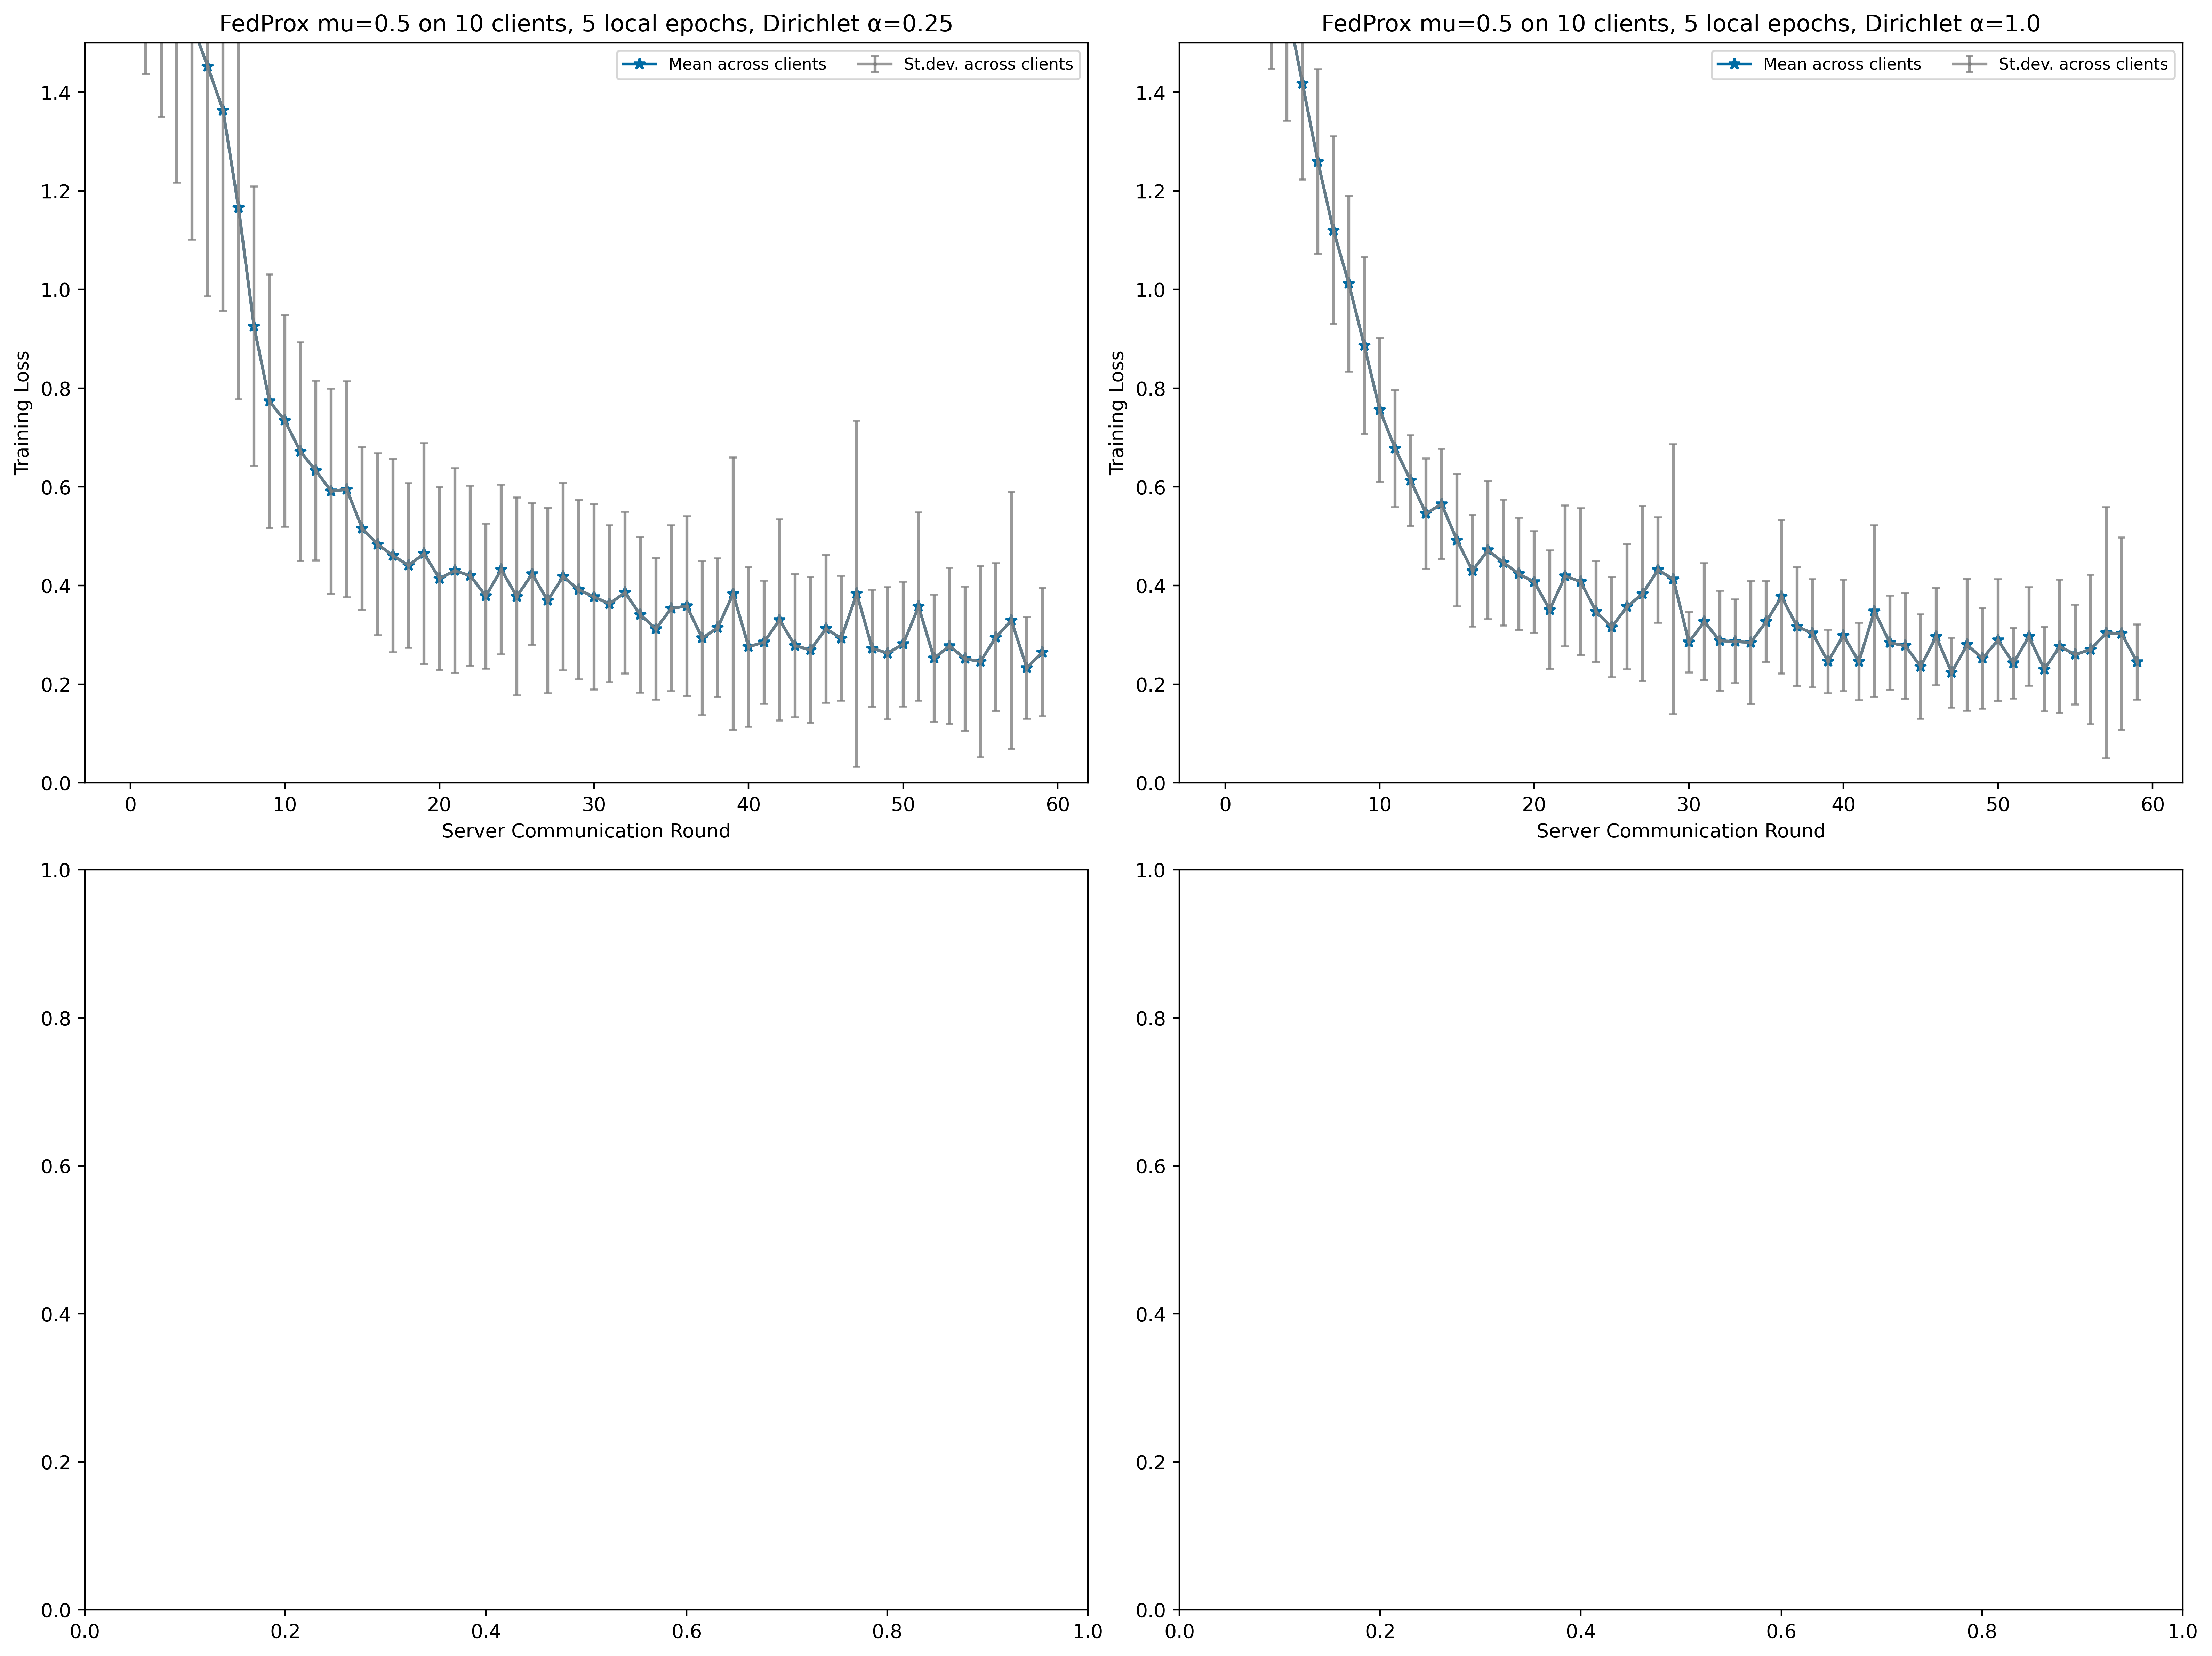

In [72]:
similarities = [0.25, 1.0] #, 2.5, 20

# Initialize a 2x2 figure grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=400)
axes = axes.flatten()  # Flatten 2D array [2,2] to 1D [4] for easy iteration

for idx, similarity in enumerate(similarities):
    # Select the specific subplot axis for this similarity value
    ax = axes[idx]
    filename = f"../fedprox/10cl/d{similarity}-prox0.5/clients10-partitioningdirichlet{similarity}-prox0.5-loceps5.jsonl"
    # Load and process data
    jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
    per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(15)]

    # PRESERVED LOGIC: Plotting all 10 clients per subplot
    per_client_coll = []

    for i, client in enumerate(per_client):
        if len(client["train_loss"].values) > 0:
            per_client_coll.append(client["train_loss"].values)
        else:
            pass
            #print(f"Client {i} has no training loss values.")

    per_client_coll = np.array(per_client_coll)

    #for i in range(10):
    ax.plot(
        np.arange(60), 
        np.mean(per_client_coll, axis=0), 
        label=f"Mean across clients", 
        marker="*", 
        #linestyle="dotted"
    )
    ax.errorbar(
        np.arange(60),
        np.mean(per_client_coll, axis=0),
        yerr=np.std(per_client_coll, axis=0),
        label="St.dev. across clients",
        fmt='-o',
        capsize=2,
        markersize=1,
        color='grey',
        alpha=0.8,
    )

    # PRESERVED LOGIC: Individual plot formatting
    ax.set_ylim(0, 1.5)
    ax.set_xlabel("Server Communication Round")
    ax.set_ylabel("Training Loss")
    ax.set_title(f"FedProx mu=0.5 on 10 clients, 5 local epochs, Dirichlet α={similarity}")
    ax.legend(loc='upper right', frameon=True, fontsize='small', ncol=2)

# Final formatting and saving
plt.tight_layout()
plt.savefig("combined-fedprox-cl10.png", dpi=400)
plt.show()
# flip order from more iid --> non-iid

In [20]:
per_client_coll = []

for i, client in enumerate(per_client):
    if len(client["train_loss"].values) > 0:
        per_client_coll.append(client["train_loss"].values)
    else:
        pass
        #print(f"Client {i} has no training loss values.")

per_client_coll = np.array(per_client_coll)
print(per_client_coll.shape)

, np.std(per_client_coll, axis=0)

(10, 60)


(array([1.23959939, 1.04829438, 0.78483109, 0.59415615, 0.39753961,
        0.24713539, 0.17084363, 0.14526668, 0.13709995, 0.11972011,
        0.10735047, 0.0990307 , 0.09610849, 0.08690323, 0.07939485,
        0.08337503, 0.07305274, 0.07635732, 0.07609398, 0.07895617,
        0.07460817, 0.06843849, 0.07259506, 0.07214841, 0.06999822,
        0.07786836, 0.06554184, 0.07154422, 0.06013577, 0.0628056 ,
        0.06351496, 0.07035585, 0.06373147, 0.08526211, 0.06375831,
        0.0652413 , 0.06318944, 0.0613718 , 0.07567433, 0.06247148,
        0.07596669, 0.06985592, 0.07196022, 0.06816029, 0.05696371,
        0.07345422, 0.06201474, 0.0627209 , 0.06310443, 0.06136137,
        0.06568352, 0.07200049, 0.08381569, 0.06201098, 0.05614734,
        0.17628271, 0.06410291, 0.07642485, 0.0687423 , 0.17972438]),
 array([0.12558334, 0.1221436 , 0.07979869, 0.07473363, 0.05842613,
        0.04299952, 0.03139913, 0.02694811, 0.03918786, 0.02990553,
        0.0231827 , 0.02067594, 0.03028183, 0.

In [ ]:
similarities = [0.25, 1.0]
mu = [0.1]

for idx, similarity in enumerate(similarities):
    # Initialize a 2x2 figure grid
    fig, axes = plt.subplots(figsize=(8, 6))
    #axes = axes.flatten()  # Flatten 2D array [2,2] to 1D [4] for easy iteration
    # Select the specific subplot axis for this similarity value
    ax = axes#[idx]
    filename = f"../fedprox/10cl/d{similarity}/clients10-partitioningdirichlet{similarity}-prox{mu[0]}-loceps5.jsonl"
    # Load and process data
    jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
    per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(15)]

    for i in range(10):
        ax.plot(
            np.arange(len(per_client[i])) + 1, 
            per_client[i]["train_loss"], 
            label=f"Client {i}", 
            #marker="*", 
            #linestyle="dotted"
        )

    # PRESERVED LOGIC: Individual plot formatting
    ax.set_ylim(0, 2.5)
    ax.set_xlabel("Server Communication Round")
    ax.set_ylabel("Training Loss")
    ax.set_title(f"FedProx μ={mu[0]}, 10 clients, Dirichlet α={similarity}")
    ax.legend(frameon=True, fontsize='x-small', ncol=2)

    # Final formatting and saving
    plt.tight_layout()
    plt.savefig("combined-fedprox-mu0.25-cl10.png", dpi=400)
    plt.show()
    # flip order from more iid --> non-iid

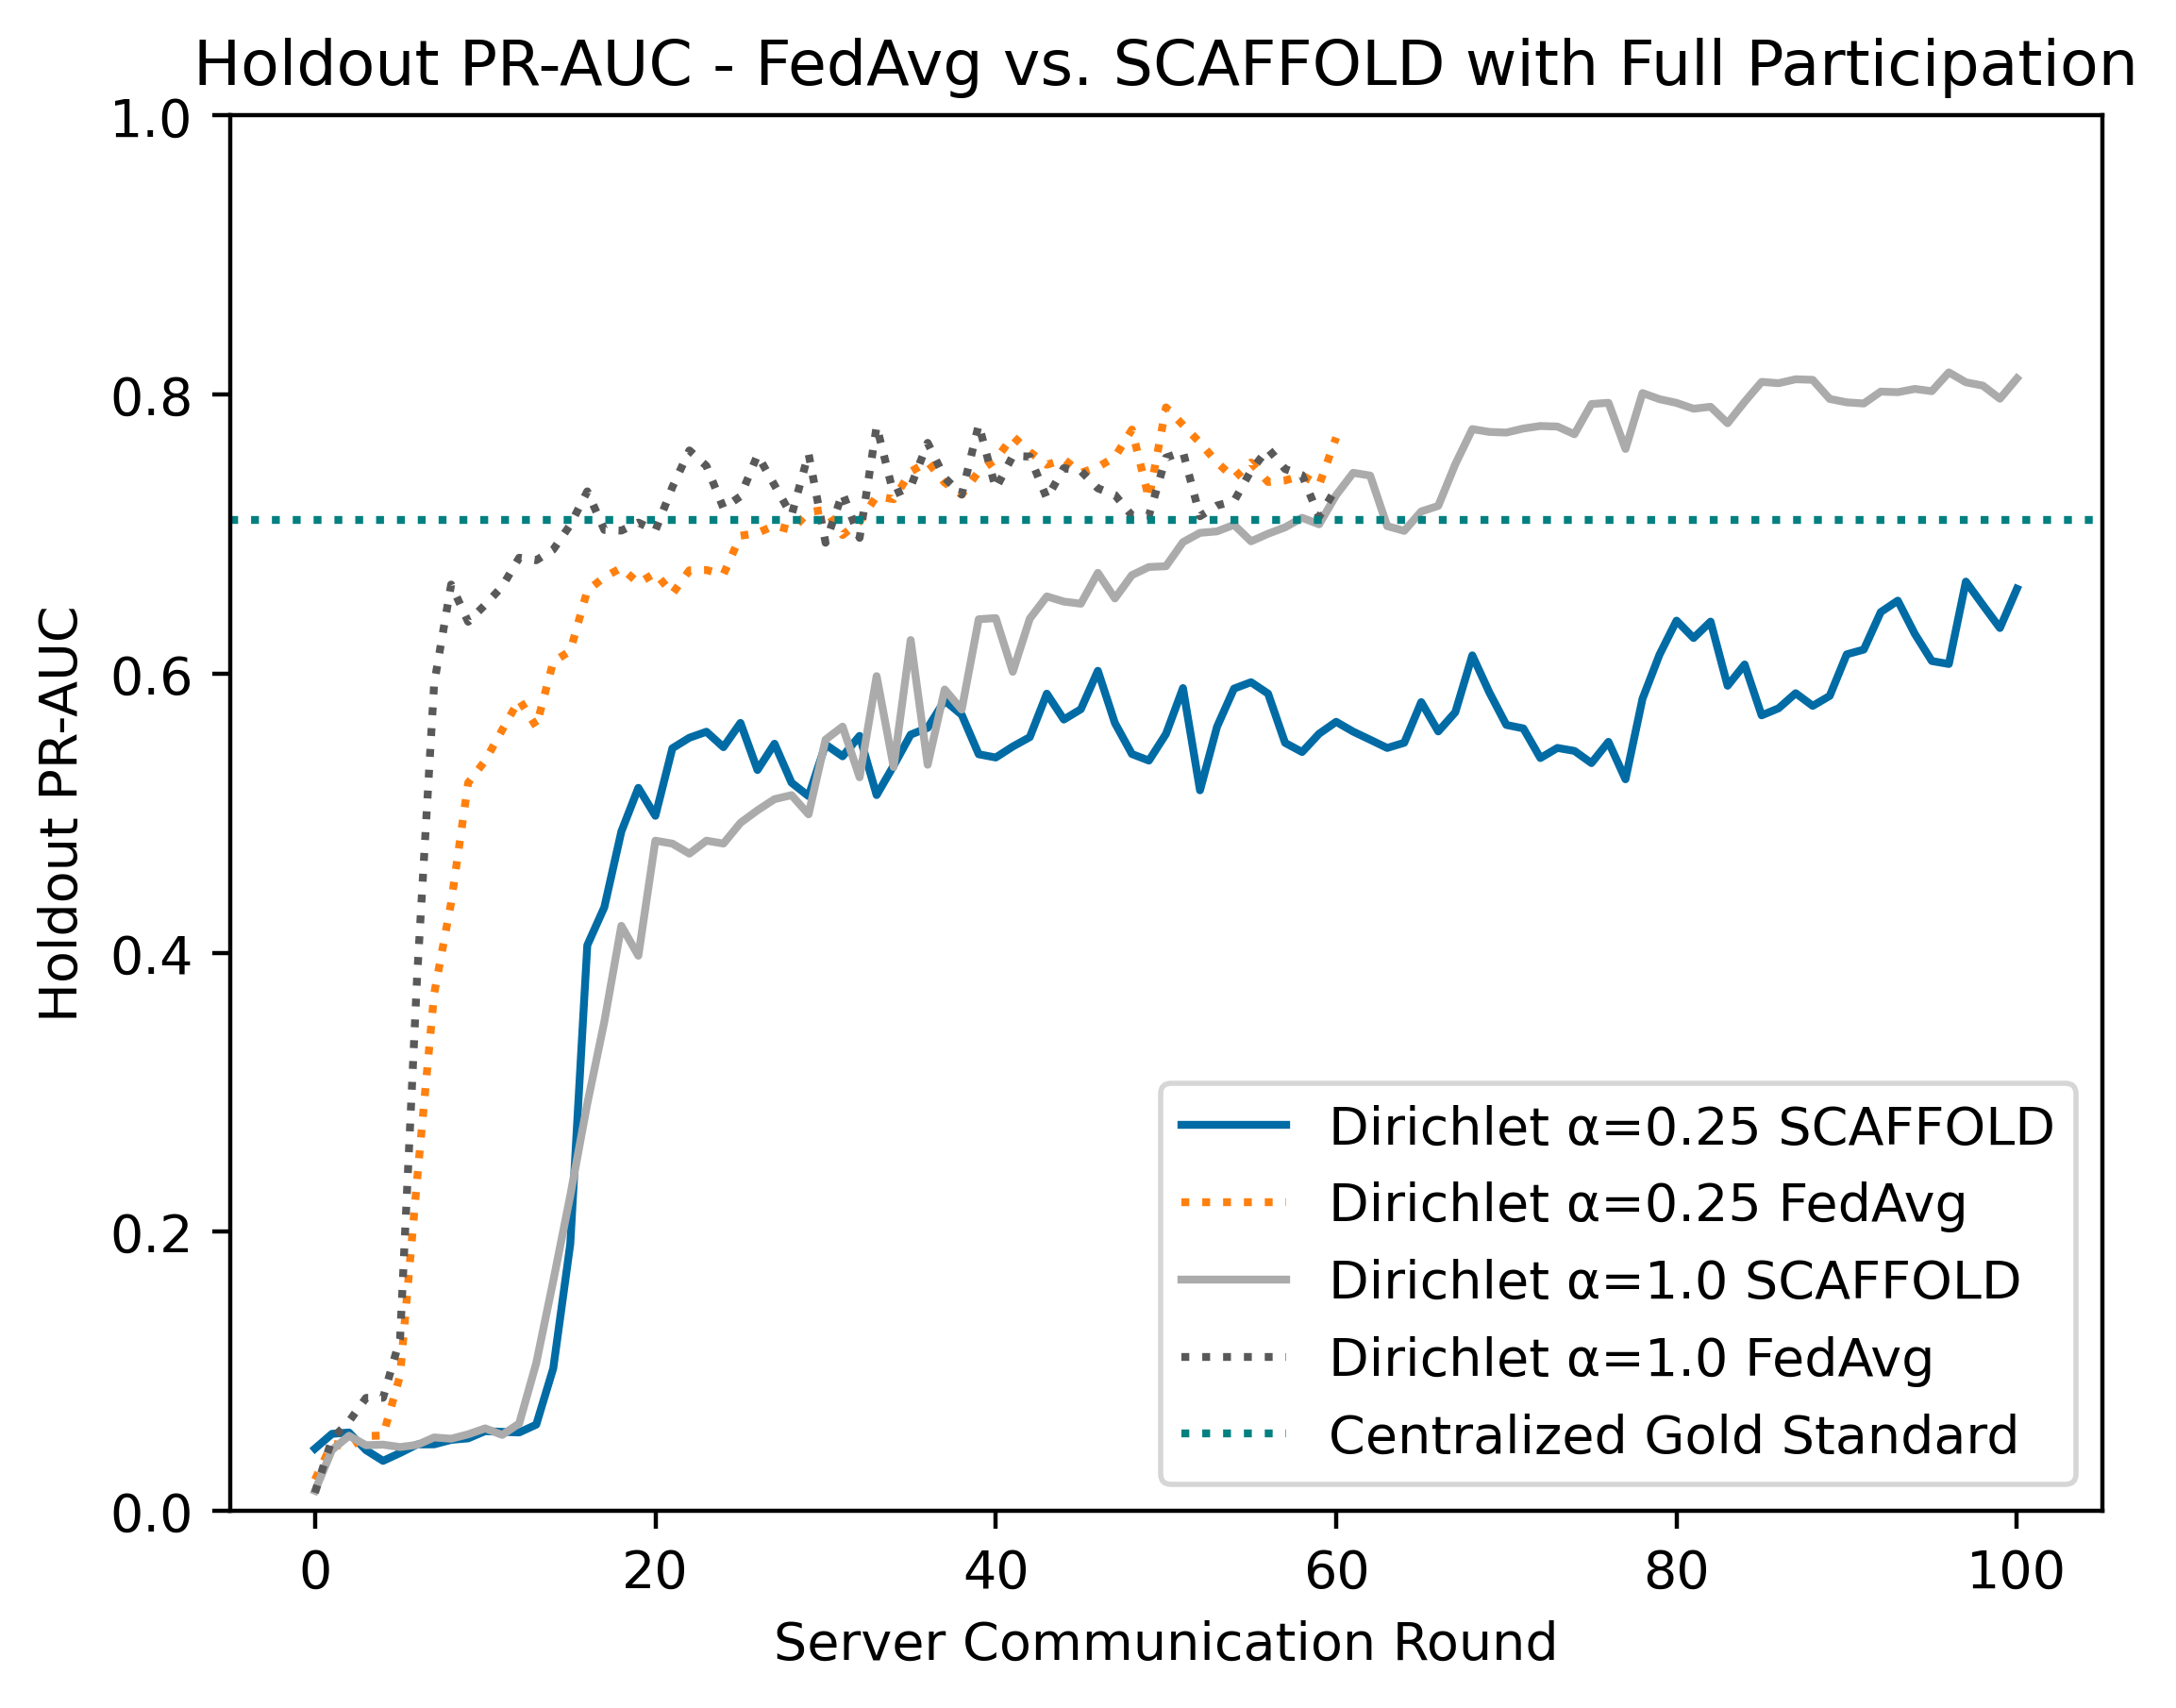

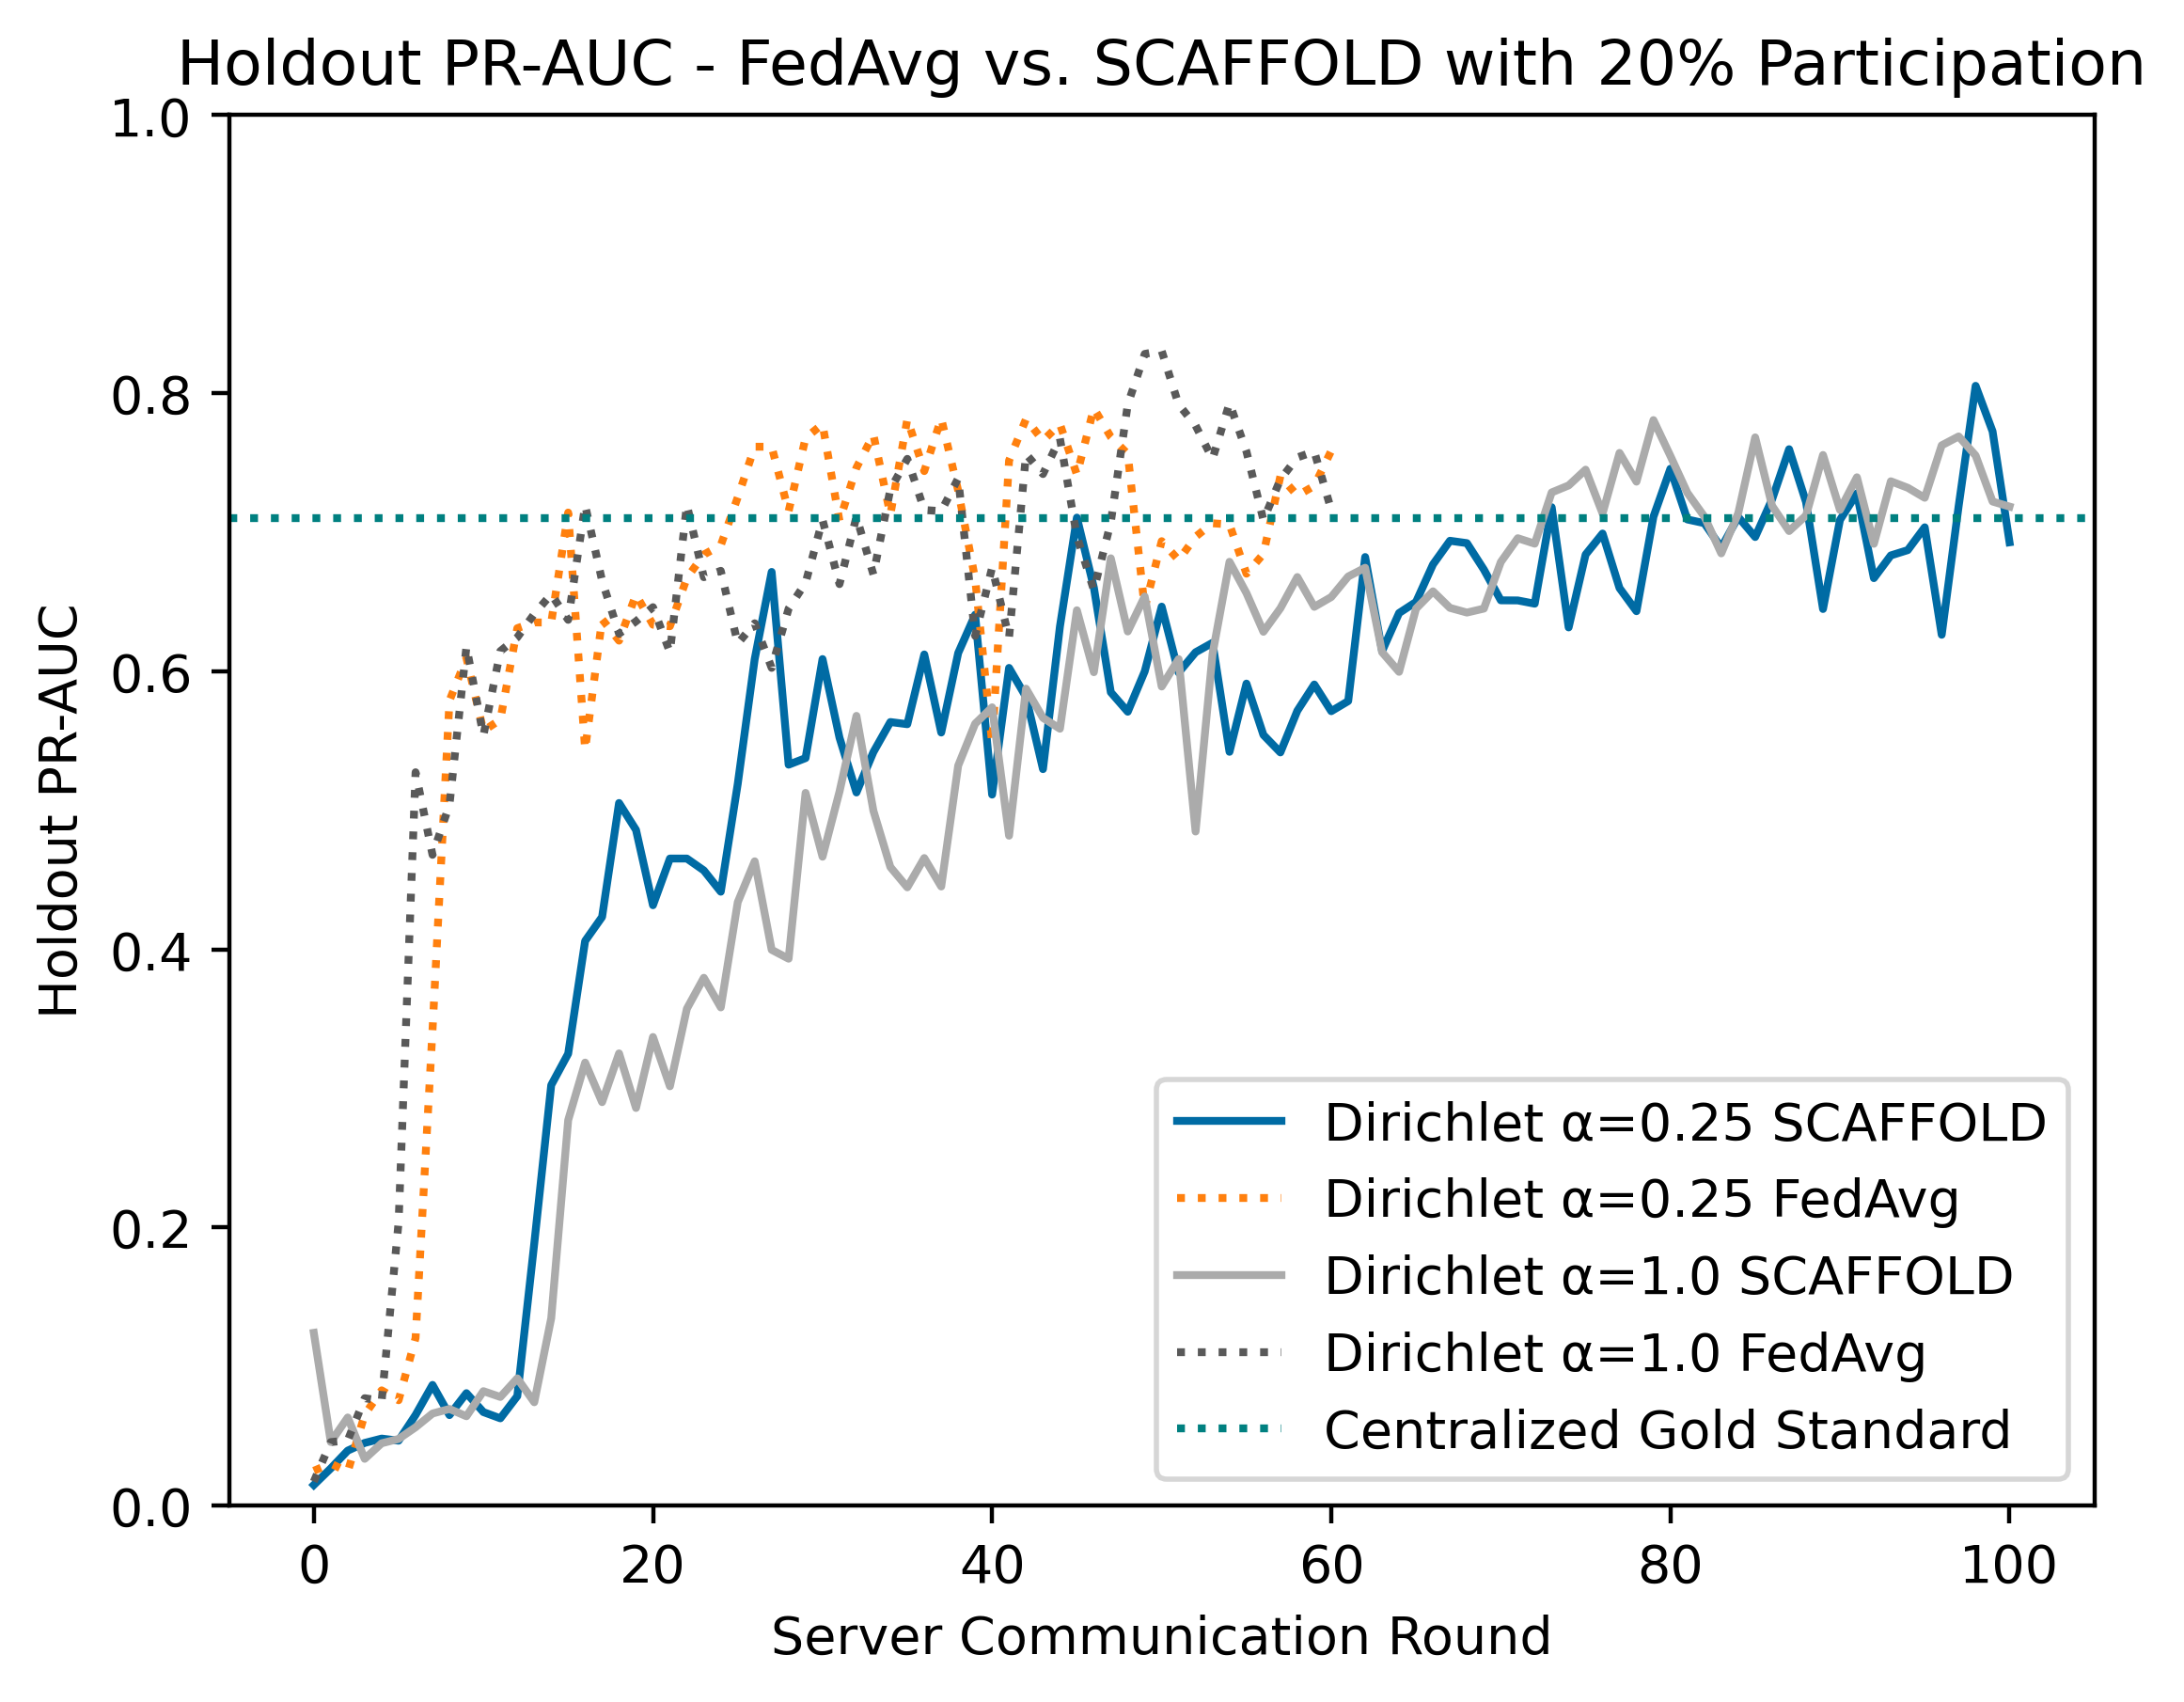

In [2]:
# similarities = [0.25, 1.0]

# # Initialize a 2x2 figure grid
# fig, axes = plt.subplots(2,1, figsize=(8, 12))
# axes = axes.flatten()  # Flatten 2D array [2,2] to 1D [4] for easy iteration

# for idx, similarity in enumerate(similarities):
#     # Select the specific subplot axis for this similarity value
#     filename = f"../scaffold/10cl-longer/d{similarity}/clients10-partitioningdirichlet{similarity}-loceps5.jsonl"
#     # Load and process data
#     jsonObj = pd.read_json(filename, lines=True, encoding="utf-8")
#     per_client = [jsonObj[jsonObj["partition_id"] == i] for i in range(15)]

#     for i in range(10):
#         axes[idx].plot(
#             np.arange(len(per_client[i])) + 1, 
#             per_client[i]["train_loss"], 
#             label=f"Client {i}", 
#             #marker="*", 
#             #linestyle="dotted"
#         )

#     # PRESERVED LOGIC: Individual plot formatting
#     axes[idx].set_ylim(0, 2.5)
#     axes[idx].set_xlabel("Server Communication Round")
#     axes[idx].set_ylabel("Training Loss")
#     axes[idx].set_title(f"SCAFFOLD, 10 clients, Dirichlet α={similarity}")
#     axes[idx].legend(frameon=True, fontsize='x-small', ncol=2)

# # Final formatting and saving
# plt.tight_layout()
# plt.savefig("combined-scaffold-cl10.png", dpi=400)
# plt.show()
# flip order from more iid --> non-iid

##################################################

similarities = [0.25, 1.0]

plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../scaffold/10cl-longer/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} SCAFFOLD", 
        #color='#59a14f',
        #marker="*", 
        #linestyle="dotted"
    )
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg vs. SCAFFOLD with Full Participation")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

######################################

plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../scaffold/10cl-longer/d{similarity}-2part/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} SCAFFOLD", 
        #color='#59a14f',
        #marker="*", 
        #linestyle="dotted"
    )
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5-0.2participation/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg vs. SCAFFOLD with 20% Participation")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

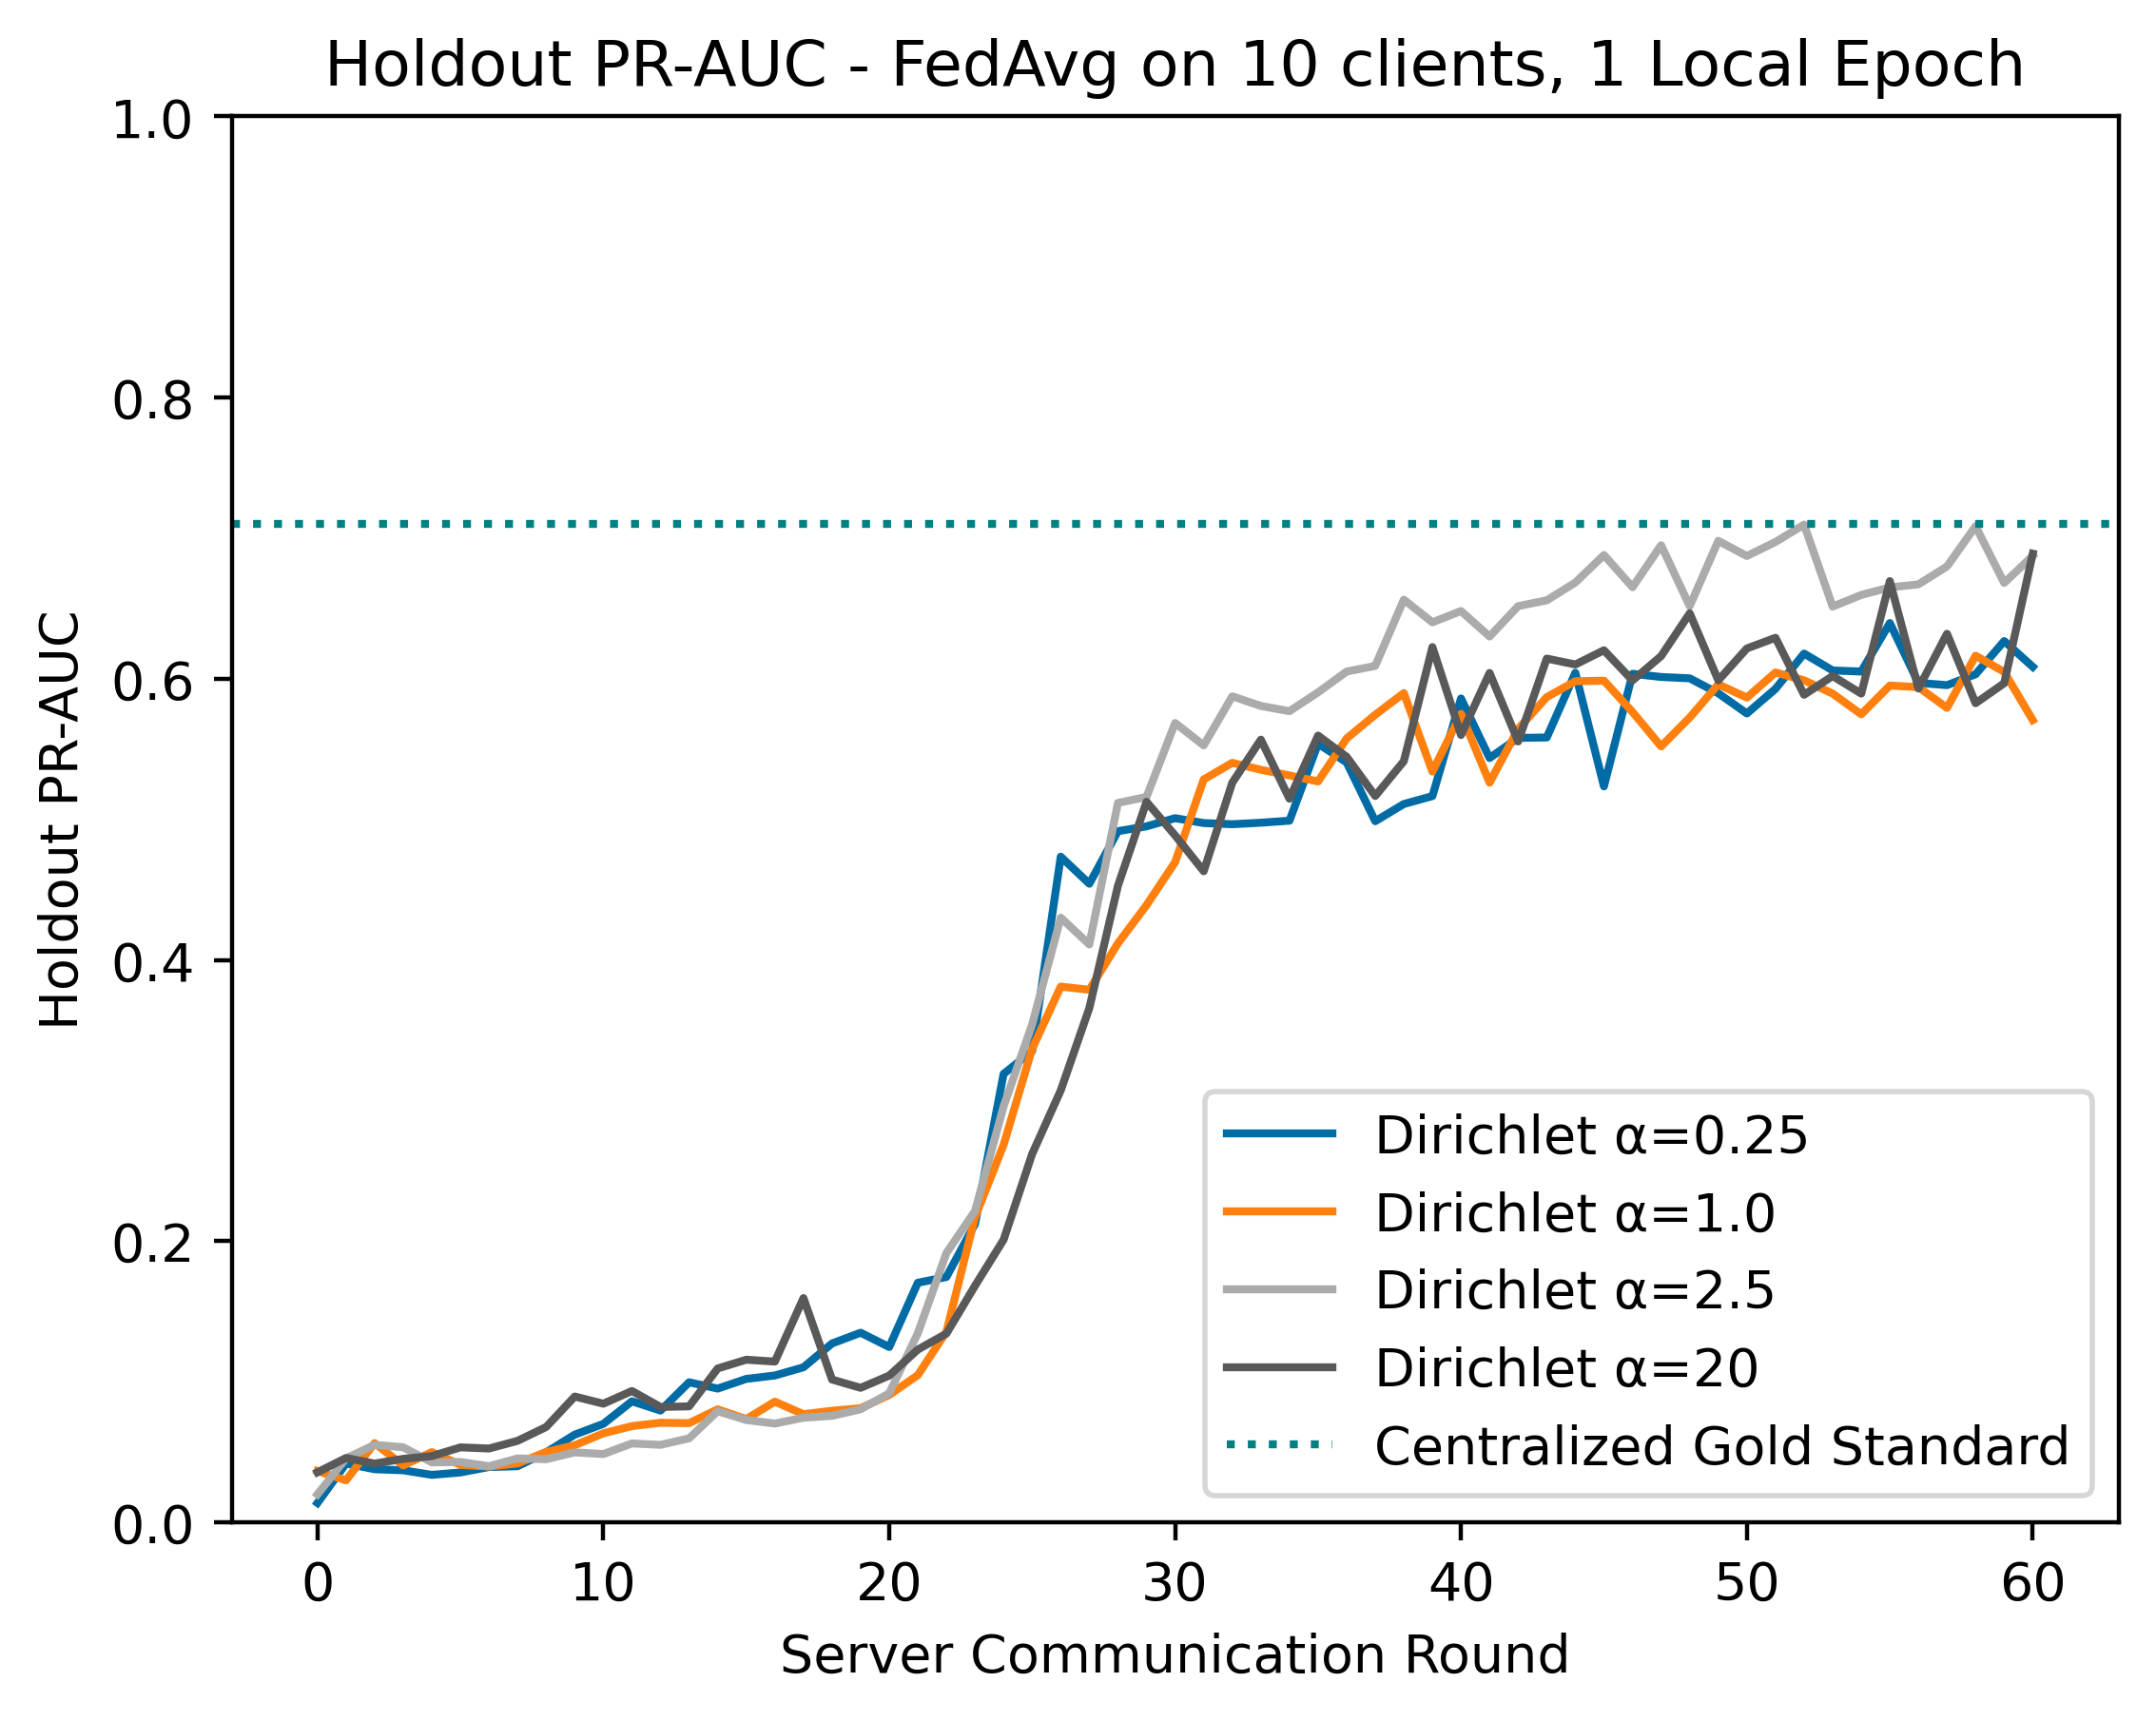

In [3]:
# similarities = [0.25, 1.0, 2.5, 20]
# plt.figure(dpi=400)
# for similarity in similarities:
#     #print(similarity)
#     jsonObj = pd.read_json(f"../fedavg/10cl/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_avg_prec']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 0.8)
# plt.axhline(y=0.65, color='teal', linestyle=':', label="Centralized Val. PR-AUC")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Validation PR-AUC")
# plt.title(f"Validation PR-AUC - FedAvg on 10 clients, 1 Local Epoch")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

# similarities = [0.25, 
#                 1.0, 2.5, 
#                 20
#                 ]
# plt.figure(dpi=400)
# for similarity in similarities:
#     jsonObj = pd.read_json(f"../fedavg/10cl/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 3.0)
# #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Server Aggregation Loss")
# plt.title(f"Server Aggregation Loss - FedAvg on 10 clients, 1 Local Epoch")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

###################################

similarities = [0.25, 1.0, 2.5, 20]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity}", 
        #marker="*", 
        #linestyle="dotted"
    )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg on 10 clients, 1 Local Epoch")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

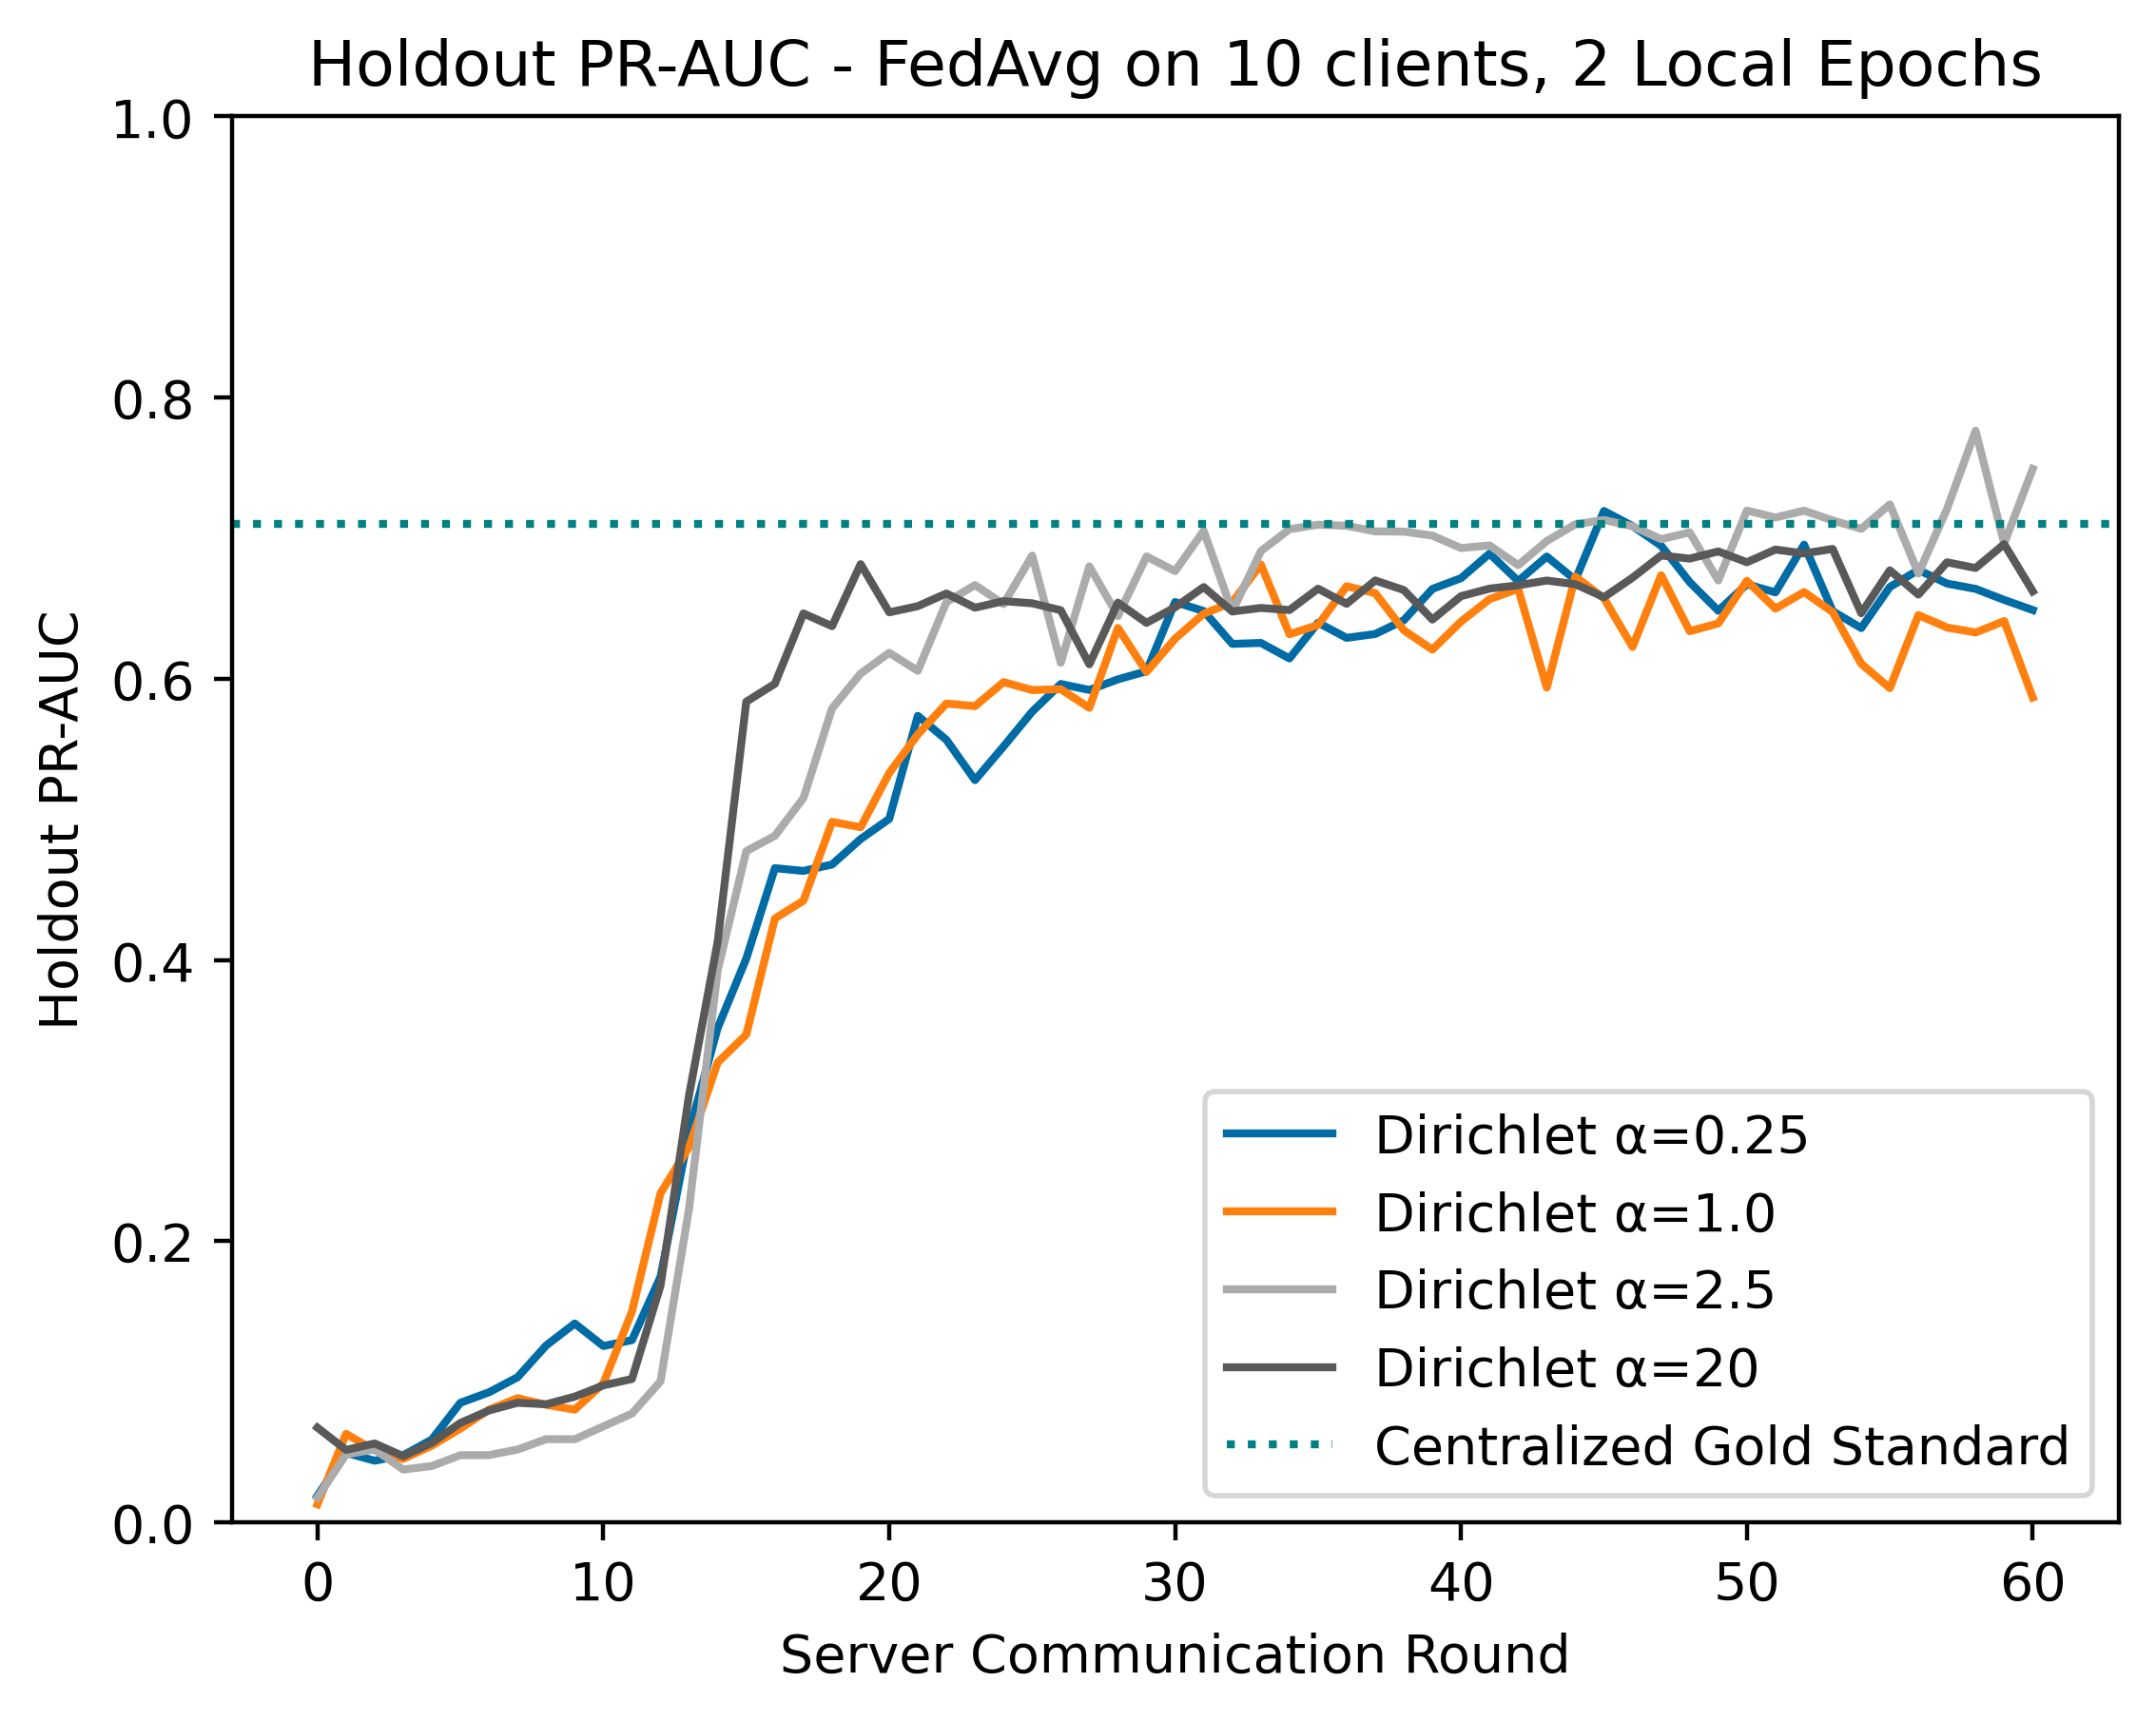

In [8]:
# similarities = [0.25, 1.0, 2.5, 20]
# plt.figure(dpi=400)
# for similarity in similarities:
#     jsonObj = pd.read_json(f"../fedavg/10cl-lep2/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_avg_prec']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 0.8)
# plt.axhline(y=0.65, color='teal', linestyle=':', label="Centralized Val. PR-AUC")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Validation PR-AUC")
# plt.title(f"Validation PR-AUC - FedAvg on 10 clients, 2 Local Epochs")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

# similarities = [0.25, 1.0, 2.5, 20]
# plt.figure(dpi=400)
# for similarity in similarities:
#     jsonObj = pd.read_json(f"../fedavg/10cl-lep2/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 3.0)
# #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Server Aggregation Loss")
# plt.title(f"Server Aggregation Loss - FedAvg on 10 clients, 2 Local Epochs")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

#####################################

similarities = [0.25, 1.0, 2.5, 20]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep2/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity}", 
        #marker="*", 
        #linestyle="dotted"
    )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg on 10 clients, 2 Local Epochs")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

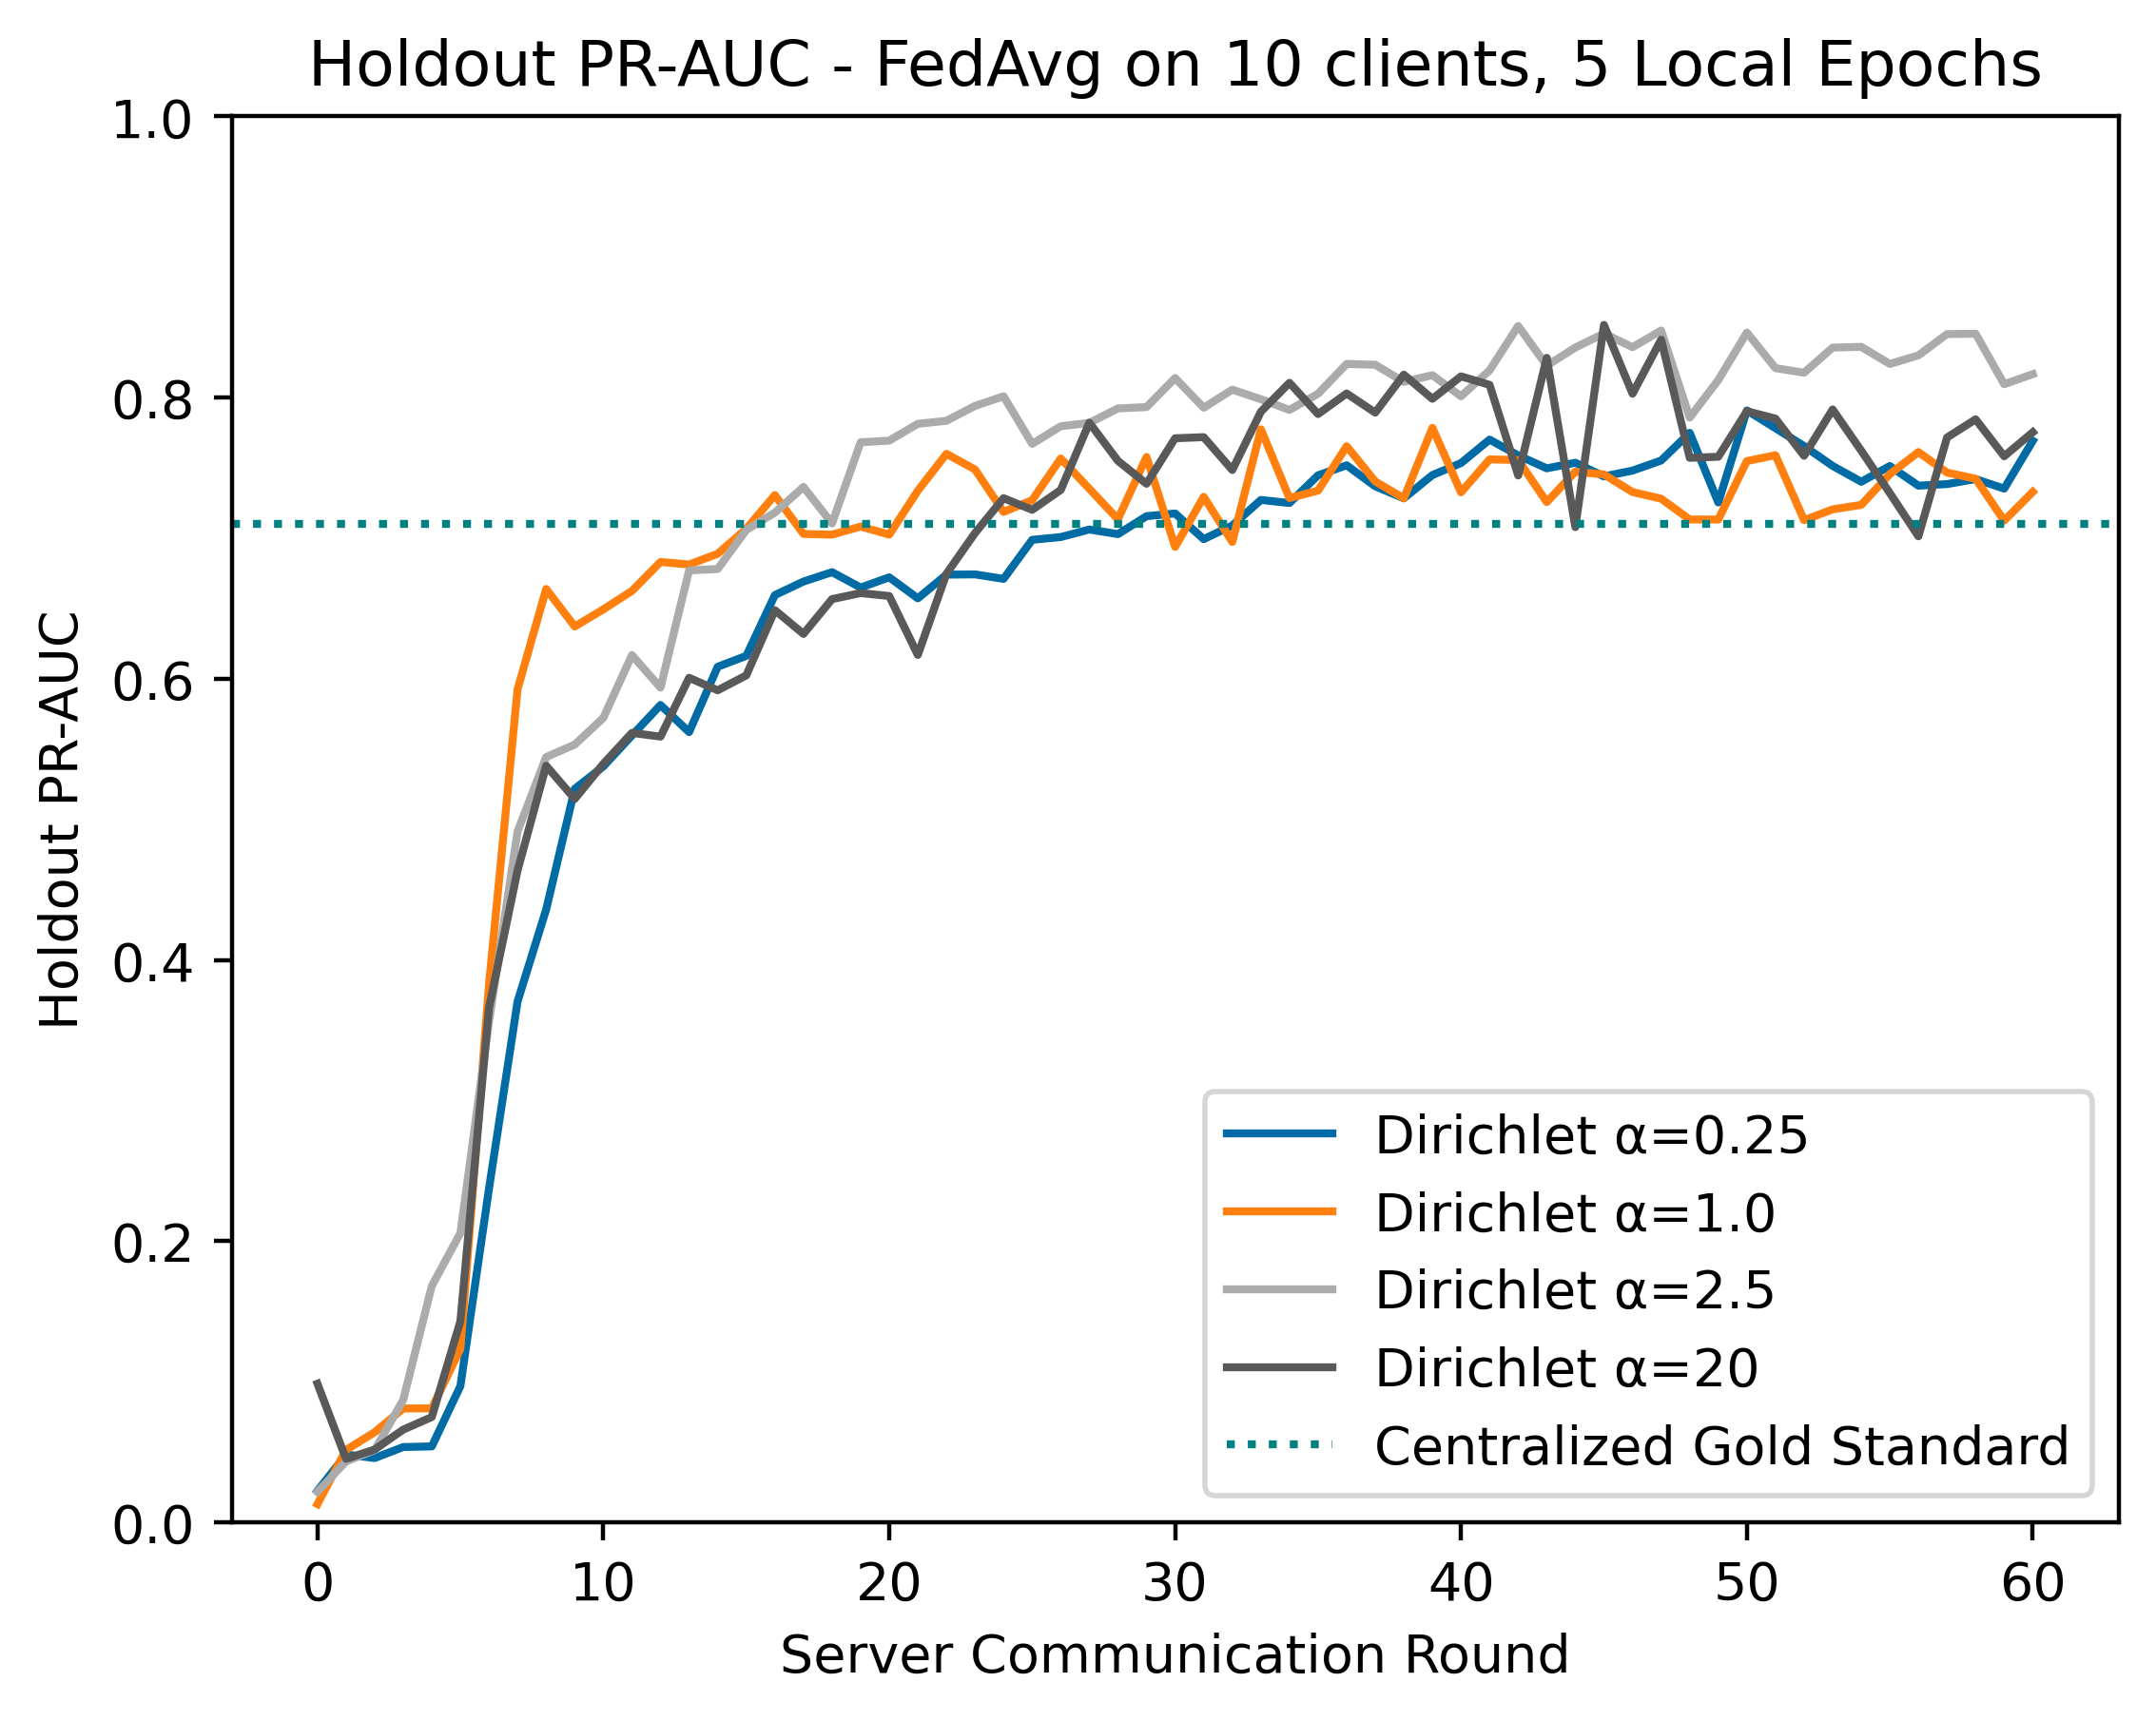

In [7]:
# similarities = [0.25, 1.0, 2.5, 20
#                 ]
# plt.figure(dpi=400)
# for similarity in similarities:
#     jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_avg_prec']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 0.8)
# plt.axhline(y=0.65, color='teal', linestyle=':', label="Centralized Val. PR-AUC")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Validation PR-AUC")
# plt.title(f"Validation PR-AUC - FedAvg on 10 clients, 5 Local Epochs")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

# ###################################

# similarities = [0.25, 1.0, 2.5, 20
#                 ]
# plt.figure(dpi=400)
# for similarity in similarities:
#     jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity}", 
#         #marker="*", 
#         #linestyle="dotted"
#     )

# # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
# plt.ylim(0.0, 5.0)
# #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
# plt.xlabel("Server Communication Round")
# plt.ylabel("Server Aggregation Loss")
# plt.title(f"Server Aggregation Loss - FedAvg on 10 clients, 5 Local Epochs")
# plt.legend(frameon=True)
# #plt.savefig(f"results.png", dpi=400)
# plt.show()

###################################

similarities = [0.25, 1.0, 2.5, 20]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity}", 
        #marker="*", 
        #linestyle="dotted"
    )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg on 10 clients, 5 Local Epochs")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

In [ ]:
similarities = [0.25, 1.0, 2.5, 20]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5-0.2participation/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity}", 
        #marker="*", 
        #linestyle="dotted"
    )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg, 10 clients, E=5 with 20% Participation")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

###################################

similarities = [0.25, 1.0, 2.5, 20]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5-0.2participation/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity}", 
        #marker="*", 
        #linestyle="dotted"
    )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 7.0)
#plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Server Aggregation Loss")
plt.title(f"Server Aggregation Loss - FedAvg, 10 clients, E=5 with 2 Sampled Participants")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

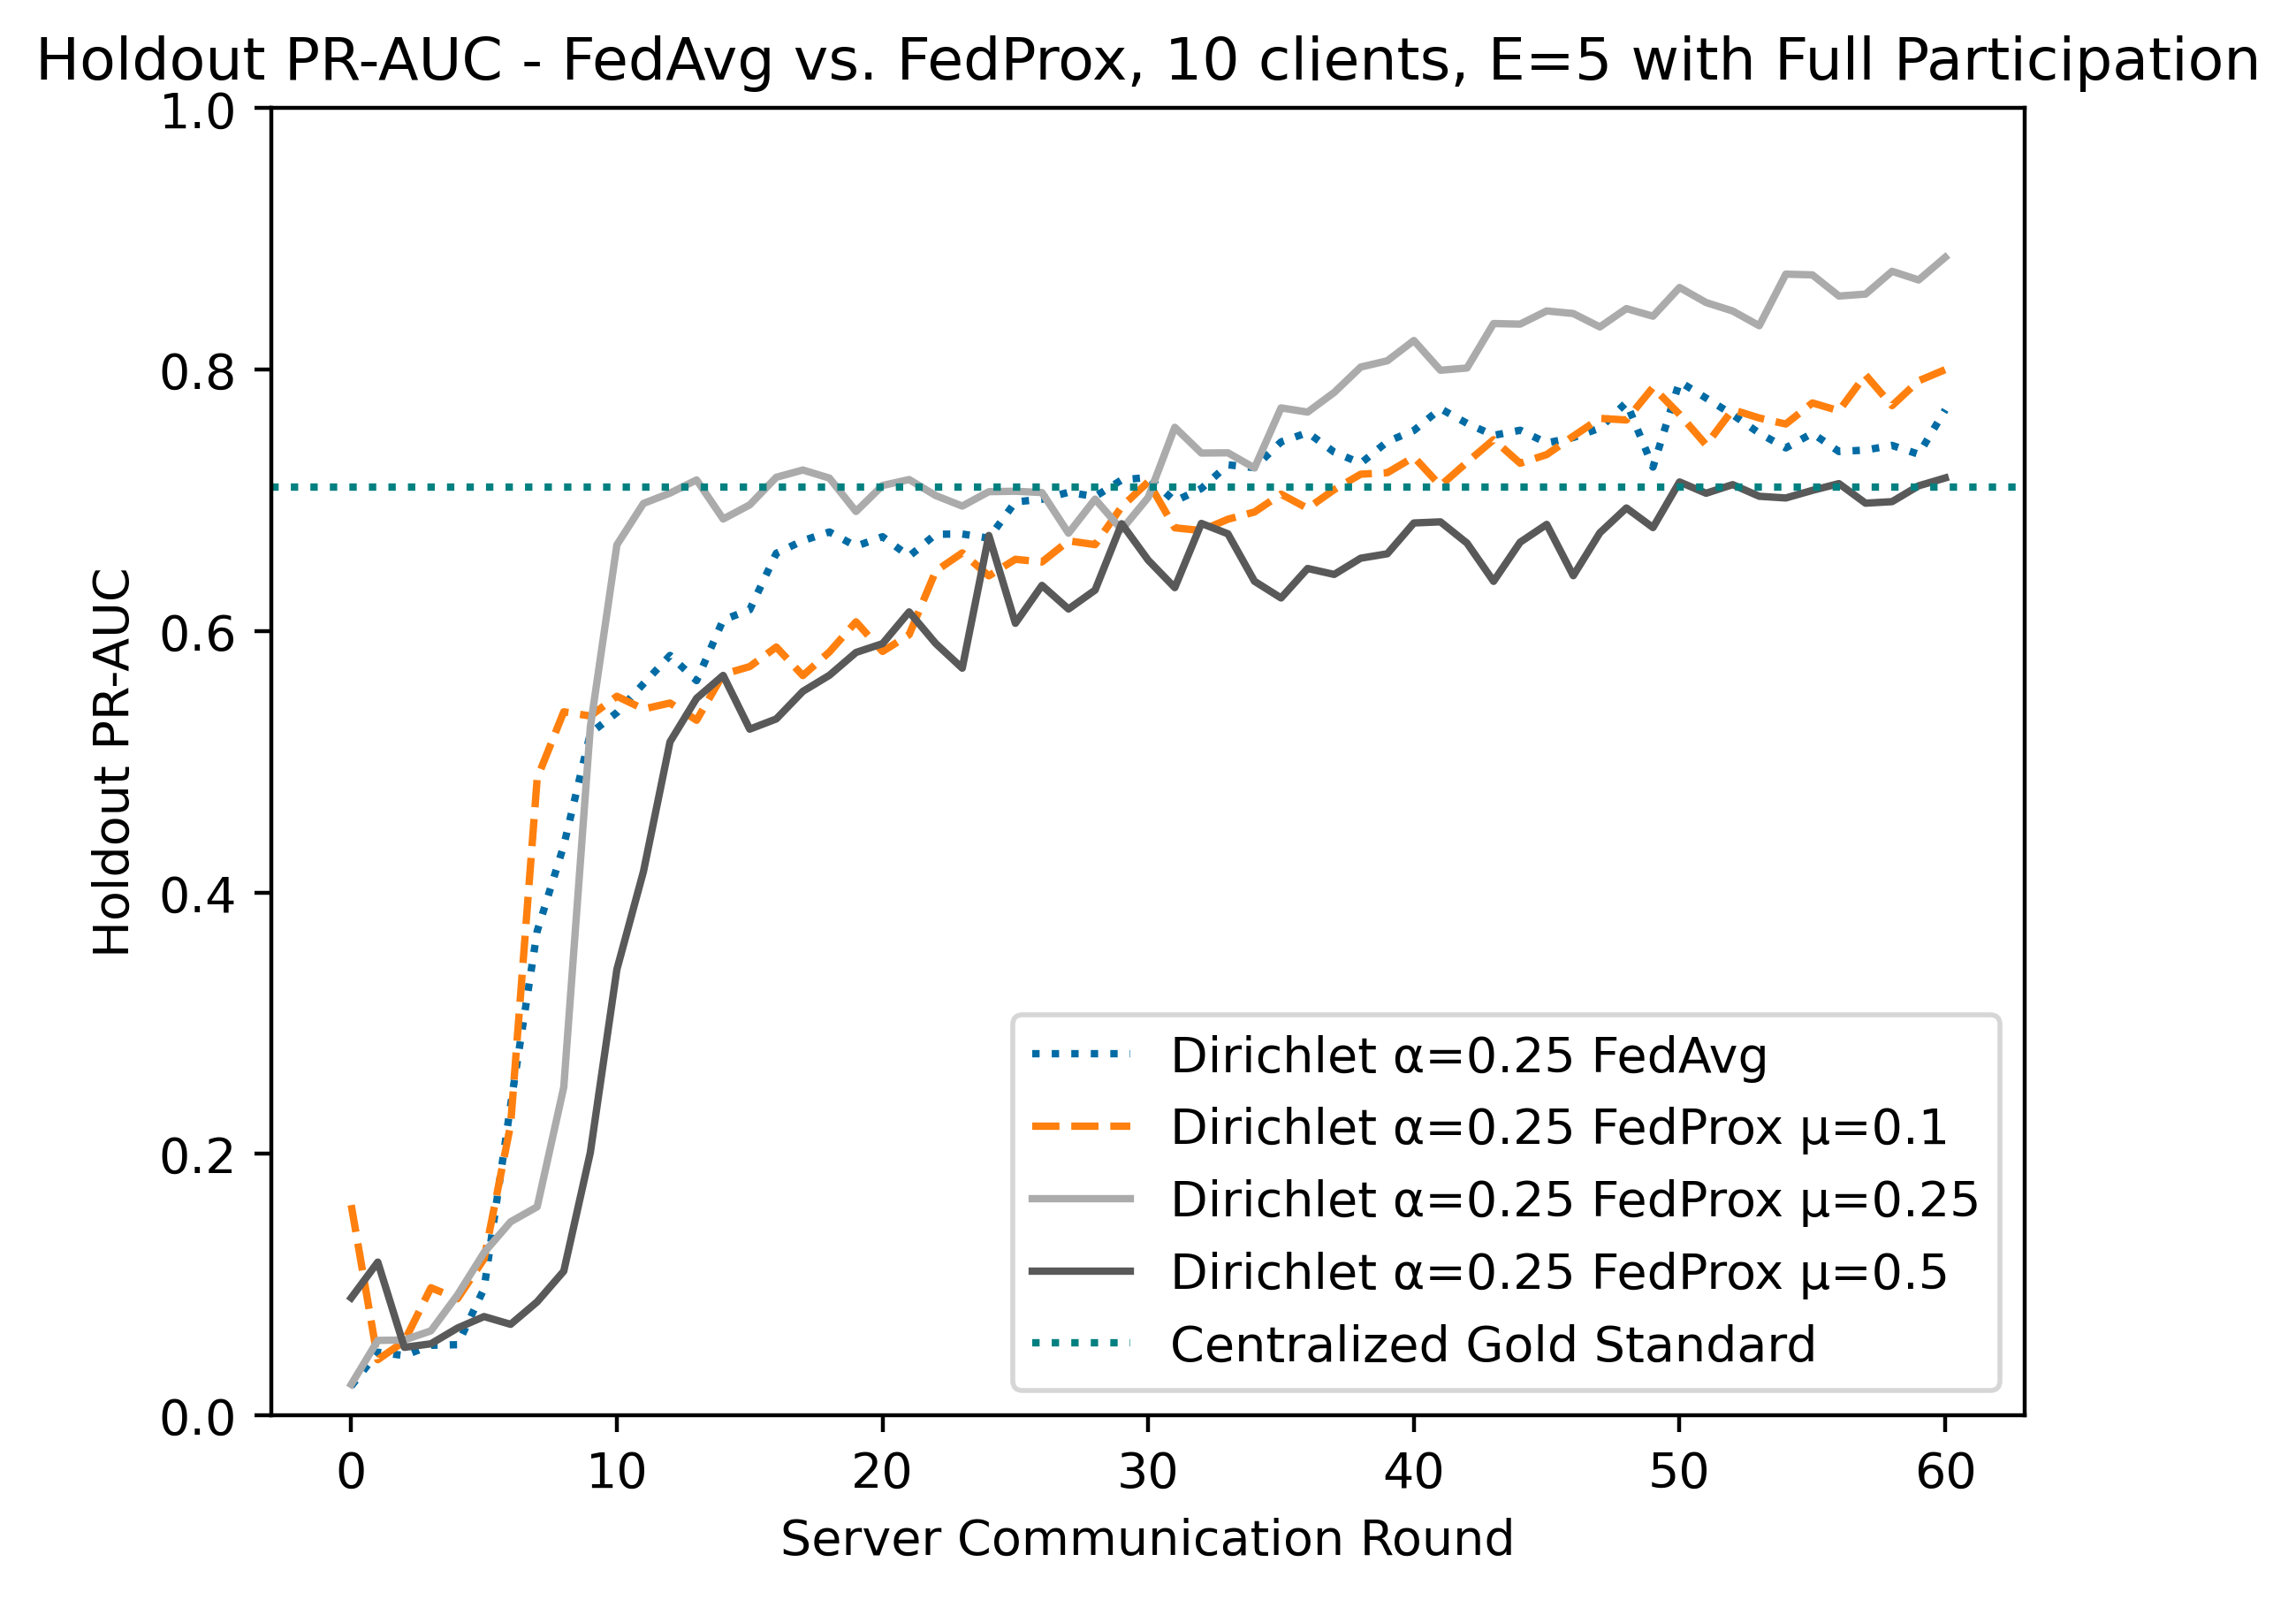

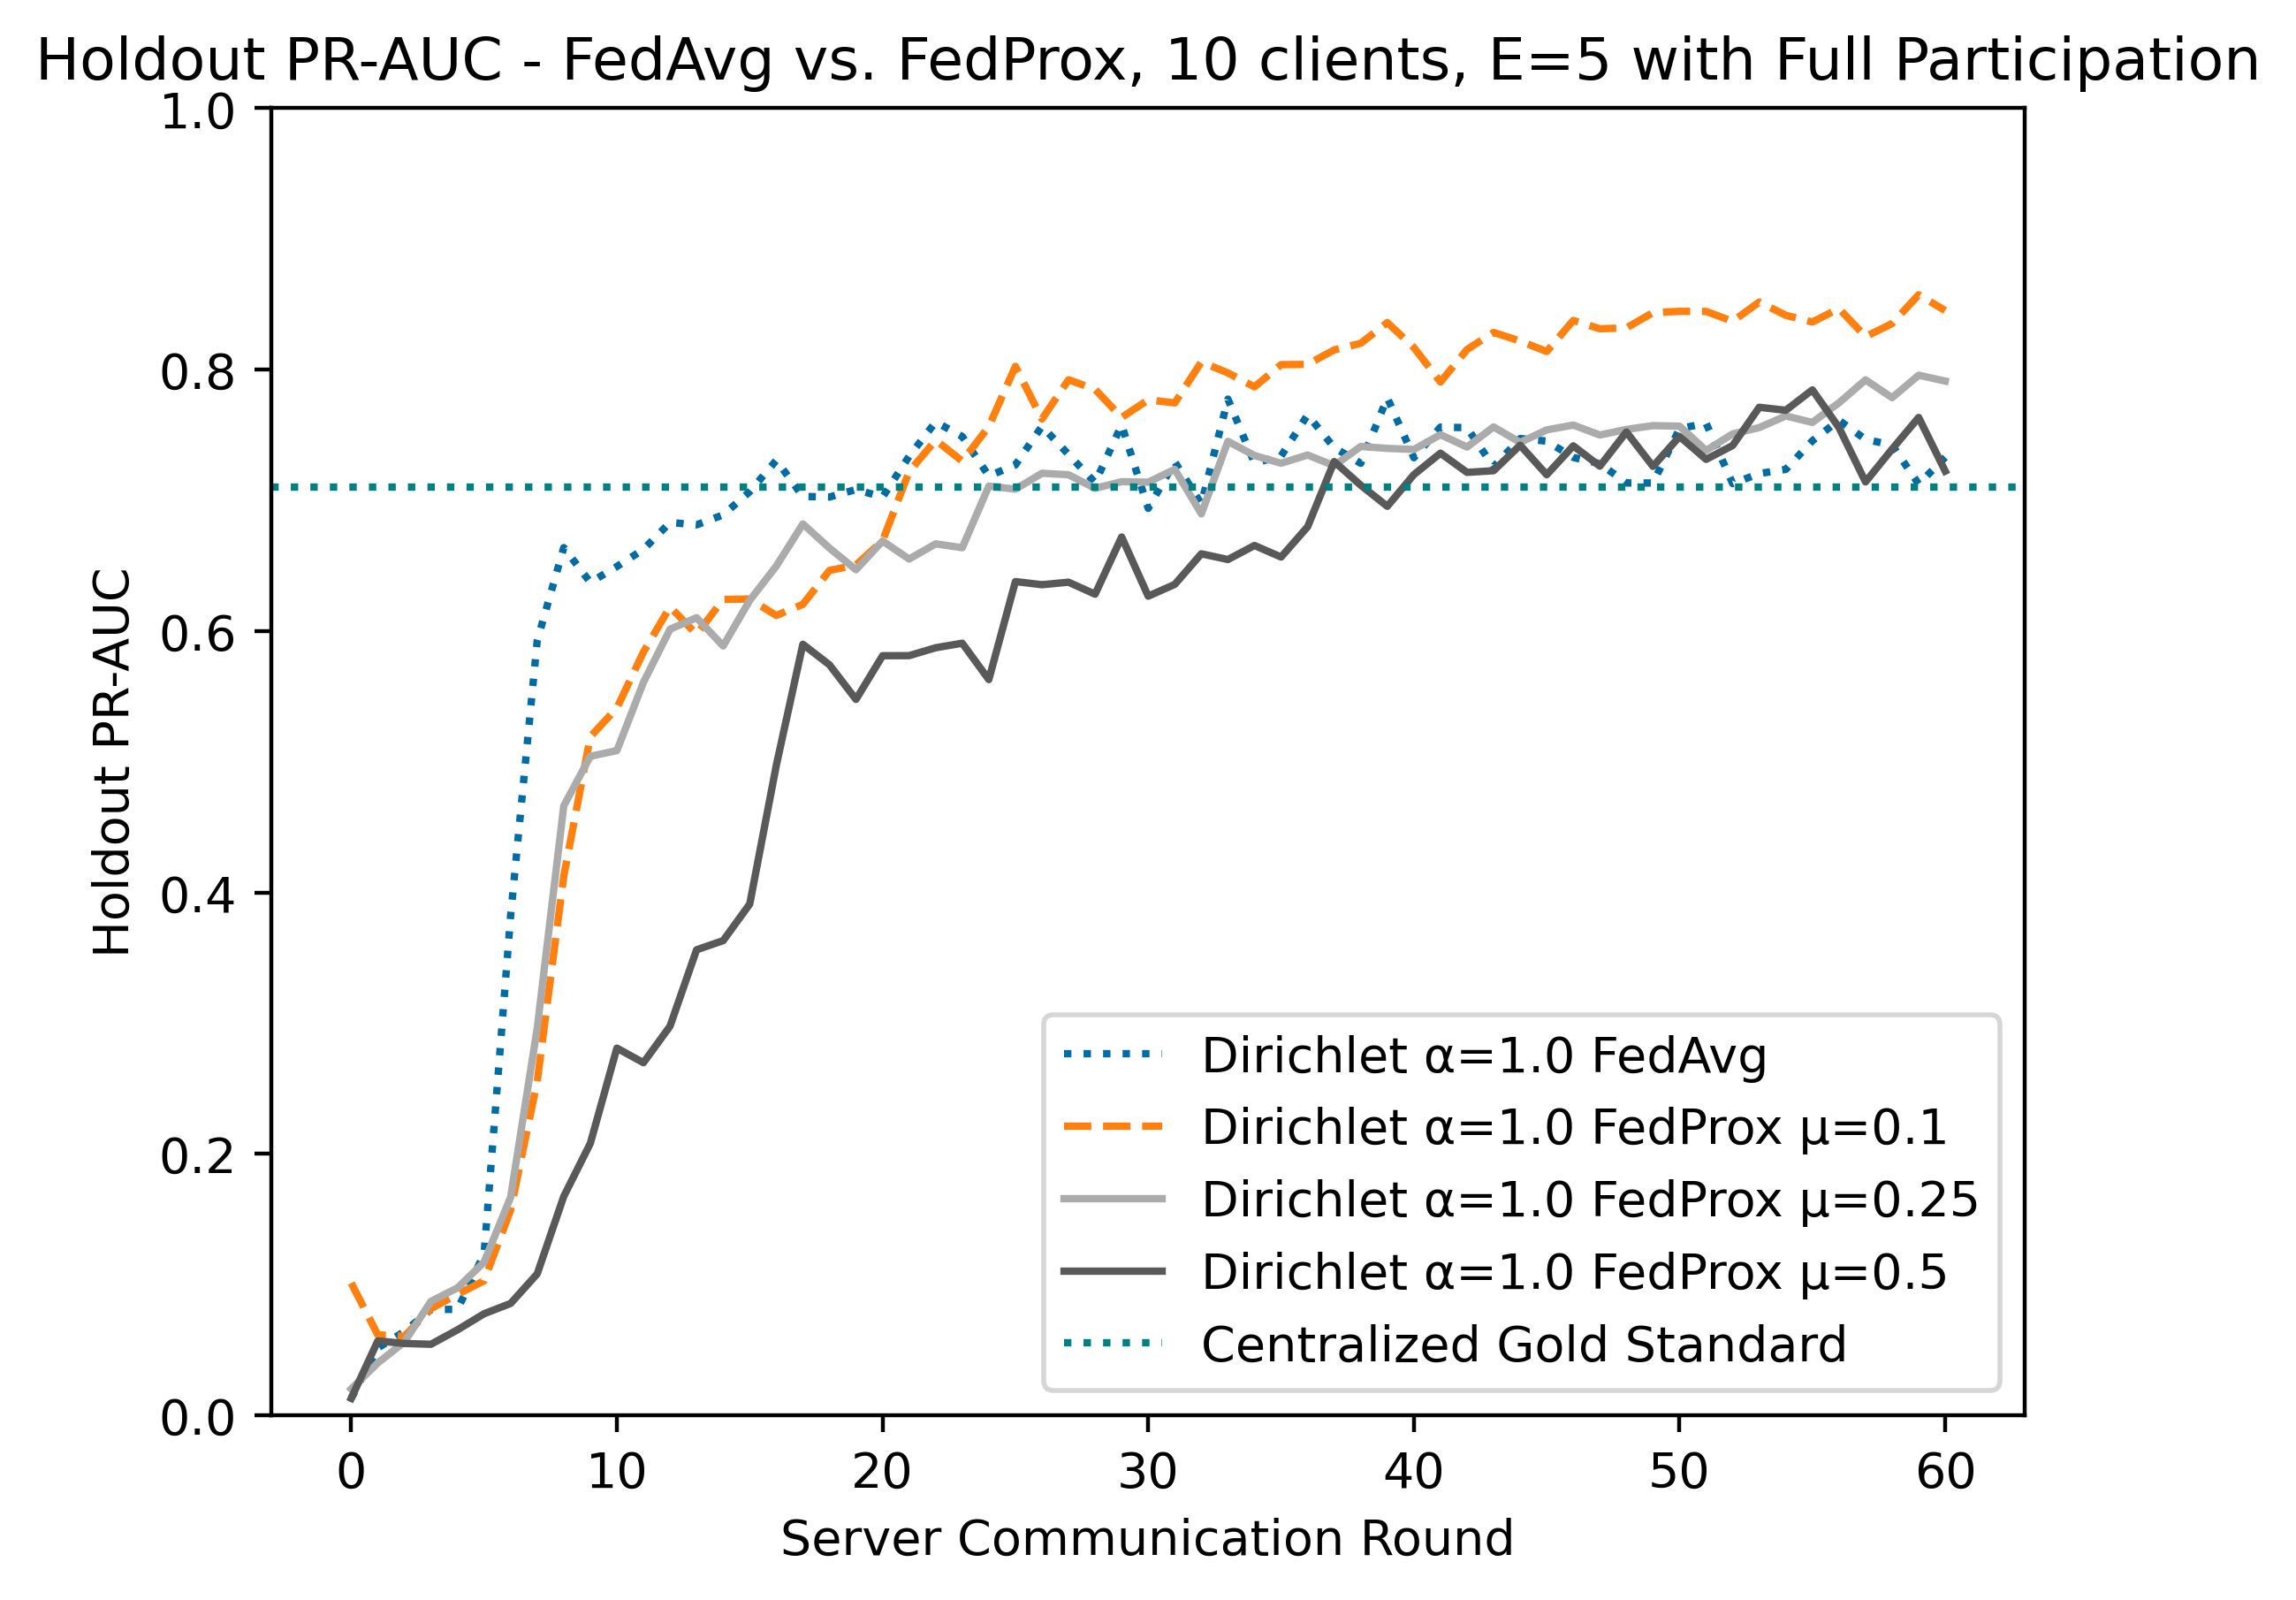

In [4]:
# similarities = [0.25,1.0 #,2.5, 20
#                 ]

# for similarity in similarities:
#     plt.figure(dpi=400)
#     jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedAvg", 
#         #marker="*", 
#         linestyle="dotted"
#     )
#     jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.1", 
#         #marker="*", 
#         linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.25/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.25", 
#         #marker="*", 
#         #linestyle="dashed"
#     )
#     jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.5/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
#     plt.plot(
#         np.arange(len(jsonObj)), 
#         jsonObj, 
#         label=f"Dirichlet α={similarity} FedProx μ=0.5", 
#         #marker="*", 
#         #linestyle="dashed"
#     )
#     plt.ylim(0.0, 5.0)
#     #plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
#     plt.xlabel("Server Communication Round")
#     plt.ylabel("Server Validation Loss")
#     plt.title(f"Server Validation Loss - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
#     plt.legend(loc='upper left', frameon=True)
#     #plt.savefig(f"results.png", dpi=400)
#     plt.show()

######################################

similarities = [0.25, 1.0#, 2.5, 20
                ]

for similarity in similarities:
    plt.figure(dpi=400)
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
    jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.1", 
        #marker="*", 
        linestyle="dashed"
    )
    jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.25/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.25", 
        #marker="*", 
        #linestyle="dashed"
    )
    jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.5/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.5", 
        #marker="*", 
        #linestyle="dashed"
    )

    # add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
    plt.ylim(0.0, 1.0)
    plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
    plt.xlabel("Server Communication Round")
    plt.ylabel("Holdout PR-AUC")
    plt.title(f"Holdout PR-AUC - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
    plt.legend(frameon=True)
    #plt.savefig(f"results.png", dpi=400)
    plt.show()

In [ ]:
similarities = [0.25]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5-0.2participation/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )

jsonObj = pd.read_json(f"../fedprox/10cl-2part/d{similarity}/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
plt.plot(
    np.arange(len(jsonObj)), 
    jsonObj, 
    label=f"Dirichlet α={similarity} FedProx μ=0.1", 
    #marker="*", 
    linestyle="dashed"
)

jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.25/serveragg-metrics.jsonl", lines=True, encoding="utf-8")['serveragg_loss']
plt.plot(
    np.arange(len(jsonObj)), 
    jsonObj, 
    label=f"Dirichlet α={similarity} FedProx μ=0.25", 
    #marker="*", 
    #linestyle="dashed"
)

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 5.0)
#plt.axhline(y=0.64, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Server Validation Loss")
plt.title(f"Server Validation Loss - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
plt.legend(loc='lower right', frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

######################################

similarities = [0.25, #1.0, 2.5, 20
                ]
plt.figure(dpi=400)
for similarity in similarities:
    jsonObj = pd.read_json(f"../fedavg/10cl-lep5/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedAvg", 
        #marker="*", 
        linestyle="dotted"
    )
    jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.1", 
        #marker="*", 
        linestyle="dashed"
    )
    jsonObj = pd.read_json(f"../fedprox/10cl/d{similarity}-prox0.25/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    plt.plot(
        np.arange(len(jsonObj)), 
        jsonObj, 
        label=f"Dirichlet α={similarity} FedProx μ=0.25", 
        #marker="*", 
        #linestyle="dashed"
    )
    # jsonObj = pd.read_json(f"fedprox/10cl/d{similarity}-prox0.5/holdoutmetrics-CODETEST.jsonl", lines=True, encoding="utf-8")['gold_standard']
    # plt.plot(
    #     np.arange(len(jsonObj)), 
    #     jsonObj, 
    #     label=f"Dirichlet α={similarity} FedProx μ=0.5", 
    #     #marker="*", 
    #     #linestyle="dashed"
    # )

# add broken x axis to remove the first 5 rounds where all models perform poorly and are indistinguishable
plt.ylim(0.0, 1.0)
plt.axhline(y=0.71, color='teal', linestyle=':', label="Centralized Gold Standard")
plt.xlabel("Server Communication Round")
plt.ylabel("Holdout PR-AUC")
plt.title(f"Holdout PR-AUC - FedAvg vs. FedProx, 10 clients, E=5 with Full Participation")
plt.legend(frameon=True)
#plt.savefig(f"results.png", dpi=400)
plt.show()

## **CODE-test accuracy - Federated**
![federated-codetest-prauc](pr_curve-federated-CODEtest.png)

In [ ]:
import pickle
plt.style.use('seaborn-v0_8-white')
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100] 
labels = [str(i) for i in bins]
ages = []
similarity=0.1
num_clients = 10
filename = f"clients{num_clients}-dirichl{similarity}(5).pkl"

with open(filename, "rb") as f:
    ages = pickle.load(f)

train_counts = pd.DataFrame(ages).T
#print(train_counts)
noniid_arr = [[] for _ in range(num_clients)]
for i in range(num_clients):
    noniid_arr[i] = pd.cut(train_counts[i], bins, labels).value_counts(
        normalize=True
    )
noniid_arr = pd.DataFrame(noniid_arr).T
noniid_arr.columns = [str(i) for i in range(num_clients)]

ax = noniid_arr.T.plot.barh(stacked=True, figsize=(12, 9), fontsize=24)
plt.title(f"Client Local Dataset Distribution α={similarity}", fontsize=28)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title="Age Range", fontsize=20)

# annotations:
for c in ax.containers:   
    # format the number of decimal places and replace 0 with an empty string
    labels = [f'{w*10:.4f}%' if (w := v.get_width()) > 1 else '' for v in c]
    plt.xlabel("# of ECG examples", fontsize=20)
    plt.ylabel("Client Index", fontsize=20)
    #ax.bar_label(c, labels=sorted(labels), label_type='edge')
plt.tight_layout()
# dirichl-alpha
plt.savefig(f"{filename}.png", dpi=400)
plt.show()

In [299]:
model = ResNet1d(input_dim=(12, 4096),
                     blocks_dim=list(zip([64, 128, 196, 256, 320], # net_filter_size
                         [4096, 1024, 256, 64, 16])), # net_sequence_length
                     n_classes=1,
                     kernel_size=17,
                     dropout_rate=0.4)
loc = torch.device('cpu')
snapshot = torch.load("1877348-snapshot.pt", map_location=loc)
model.load_state_dict(snapshot["MODEL_STATE"])

model.eval()
for i, filepath in enumerate(glob.glob("code-test/*.csv")):
    f = h5py.File("code-test/ecg_tracings.hdf5", 'r')
    traces = torch.tensor(np.array(f['tracings'], dtype=np.float32), dtype=torch.float32).transpose(2, 1)
    y_trues = torch.tensor(pd.read_csv(filepath)["AF"], dtype=torch.float16).reshape(-1,1)

    # Run forward pass
    with torch.no_grad():
        y_preds = model(traces).numpy()
    
    PrecisionRecallDisplay.from_predictions(y_trues, y_preds) 
    plt.title(f"PR-Curve on Annotated ECG Dataset - gold_standard.png")
    plt.savefig(f"pr_curve-federated-CODEtest.png", dpi=300)
    plt.close()

## **CODE-test accuracy - Centralized**
![centralized-codetest](pr_curve-centralized-CODEtest.png)

In [ ]:
import os, time
import torch
import torch.nn as nn
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import glob
from torch.nn.parallel import DistributedDataParallel as DDP
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
from resnet import ResNet1d

In [ ]:
model = ResNet1d(input_dim=(12, 4096),
                     blocks_dim=list(zip([64, 128, 196, 256, 320], # net_filter_size
                         [4096, 1024, 256, 64, 16])), # net_sequence_length
                     n_classes=1,
                     kernel_size=17,
                     dropout_rate=0.4)
loc = torch.device('cpu')
snapshot = torch.load("1877348-snapshot.pt", map_location=loc)
model.load_state_dict(snapshot["MODEL_STATE"])
#print(model)

model.eval()
for i, filepath in enumerate(glob.glob("code-test/*.csv")):
    f = h5py.File("code-test/ecg_tracings.hdf5", 'r')
    traces = torch.tensor(np.array(f['tracings'], dtype=np.float32), dtype=torch.float32).transpose(2, 1)
    y_trues = torch.tensor(pd.read_csv(filepath)["AF"], dtype=torch.float16).reshape(-1,1)

    # Run forward pass
    with torch.no_grad():
        y_preds = model(traces).numpy()
        ConfusionMatrixDisplay.from_predictions(y_trues.numpy(), np.argmax(y_preds, axis=1))
        plt.show()

    plt.title(f"PR-Curve on Annotated ECG Dataset - gold_standard.png")
    plt.savefig(f"pr_curve-centralized-CODEtest.png", dpi=300)
    plt.close()

In [ ]:
# specificity = tn / (tn+fp) 0%
# sensitivity = tp / (tp+fn) 100%

disp = ConfusionMatrixDisplay.from_predictions(y_trues.numpy(), np.argmax(y_preds, axis=1))
disp.plot(cmap=plt.cm.BuGn)
ax = disp.ax_

# Define labels and their corresponding matrix coordinates (row, col)
# Format: (label, row, col)
labels = [
    ("TP", 0, 0), ("FN", 0, 1),
    ("FP", 1, 0), ("TN", 1, 1)
]

for label, row, col in labels:
    # ax.text(x, y, string)
    # Since cell centers are at integers (0, 1), 
    # we subtract 0.4 to move toward the top-left corner.
    ax.text(col - 0.4, row - 0.35, label, 
            fontsize=10, 
            weight='bold', 
            ha='left', 
            va='top', 
            color='red')
# increase dpi
plt.savefig(f"confusion_matrix.png", dpi=400)
plt.show()
plt.close()